In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Go up one level from /notebooks to repo root
ROOT = Path.cwd().parent
CLEANED = ROOT / "data" / "processed" / "02_cleaned"

# Dual-metric datasets (loading both Percent and Number tracks + compatibility aliases)
df_cchs_mh_disorders_pct = pd.read_csv(CLEANED / "cchs_mh_disorders_pct.csv")
df_cchs_mh_disorders_n   = pd.read_csv(CLEANED / "cchs_mh_disorders_n.csv")
df_cchs_mh_disorders     = df_cchs_mh_disorders_pct

df_stress_coping_pct     = pd.read_csv(CLEANED / "stress_coping_pct.csv")
df_stress_coping_n       = pd.read_csv(CLEANED / "stress_coping_n.csv")
df_stress_coping         = df_stress_coping_pct

df_suicidal_thoughts_pct = pd.read_csv(CLEANED / "suicidal_thoughts_pct.csv")
df_suicidal_thoughts_n   = pd.read_csv(CLEANED / "suicidal_thoughts_n.csv")
df_suicidal_thoughts     = df_suicidal_thoughts_pct

df_perceived_health_quarterly_pct = pd.read_csv(CLEANED / "perceived_health_quarterly_pct.csv")
df_perceived_health_quarterly_n   = pd.read_csv(CLEANED / "perceived_health_quarterly_n.csv")
df_perceived_health_quarterly     = df_perceived_health_quarterly_pct

# Single-metric datasets
df_perceived_mh_annual   = pd.read_csv(CLEANED / "perceived_mh_annual.csv")
df_cihi_children_youth   = pd.read_csv(CLEANED / "cihi_children_youth.csv")
df_cihi_mh_services      = pd.read_csv(CLEANED / "cihi_mh_services.csv")
df_mhacs_2022_pumf       = pd.read_csv(CLEANED / "mhacs_2022_pumf.csv")

print("All datasets loaded successfully (both Percent and Count tracks).")


In [2]:
df_cchs_mh_disorders.head()

,ref_date_raw,start_year,geo,sex,age_group,indicator,value,ci_low,ci_high,metric_type,quality_flag
0,2002,2002,Alberta,Men+,15 to 24 years,"Cannabis use, 12 months",37.4,31.1,43.7,percent,NaN
1,2002,2002,Alberta,Men+,15 to 24 years,"Cannabis use, life",56.4,49.3,63.6,percent,NaN
2,2002,2002,Alberta,Men+,15 to 24 years,"Major depressive episode, 12 months",5.2,2.4,7.9,percent,E
3,2002,2002,Alberta,Men+,15 to 24 years,"Major depressive episode, life",7.1,3.7,10.4,percent,E
4,2002,2002,Alberta,Men+,15 to 24 years,"Perceived mental health, fair or poor",3.1,1.5,4.8,percent,E


In [3]:
df_cihi_children_youth.head()

,Fiscal year,Diagnosis category,Sex,fiscal_year,value,ci_low,ci_high,sheet_type
0,2018–2019,Neurocognitive disorders,Female,Agegroup:5–9years–Rate,6.0,NaN,NaN,ED
1,2018–2019,Neurocognitive disorders,Male,Agegroup:5–9years–Rate,9.0,NaN,NaN,ED
2,2018–2019,Neurocognitive disorders,Total,Agegroup:5–9years–Rate,8.0,NaN,NaN,ED
3,2018–2019,Substance-related disorders,Female,Agegroup:5–9years–Rate,1.0,NaN,NaN,ED
4,2018–2019,Substance-related disorders,Male,Agegroup:5–9years–Rate,2.0,NaN,NaN,ED


In [4]:
df_cihi_mh_services.head()

,indicator,breakdown,group,value,ci_low,ci_high
0,Self-rated mental health in youth,Sex,Males,71.8,68.4,75.2
1,Self-rated mental health in youth,Sex,Females,52.3,48.4,56.3
2,Self-rated mental health in youth,Sex,Total population,62.2,59.7,64.8
3,Happiness in youth,Sex,Males,75.7,72.1,79.3
4,Happiness in youth,Sex,Females,70.1,66.5,73.7


In [5]:
df_mhacs_2022_pumf.head()

,PUMFID,GEODVPSZ,DHHGMS,DHHGAGE,GENDER,GEN_01,GEN_02A,GEN_08B,GEN_08C,GEN_02A1,...,SDCGRES,SDCGVVM,SDCDVFLA,EDU_05,INCDVP19,INCDVP20,INCDVHH,DABTIPPE,DNBTIPPE,WTS_M
0,615402.0,3.0,1.0,NaN,1.0,2.0,3.0,2.0,3.0,3.0,...,6.0,6.0,2.0,3.0,14.0,14.0,15.0,3.0,1.0,4372.02
1,615403.0,4.0,3.0,2.0,2.0,4.0,3.0,4.0,4.0,3.0,...,6.0,6.0,2.0,6.0,5.0,5.0,13.0,10.0,NaN,2711.23
2,615404.0,4.0,1.0,NaN,1.0,2.0,3.0,3.0,3.0,2.0,...,3.0,1.0,1.0,6.0,12.0,12.0,14.0,NaN,NaN,2475.62
3,615405.0,4.0,3.0,2.0,2.0,3.0,3.0,3.0,3.0,1.0,...,6.0,5.0,1.0,6.0,5.0,6.0,14.0,2.0,4.0,2970.67
4,615406.0,4.0,3.0,2.0,1.0,2.0,2.0,2.0,1.0,2.0,...,2.0,1.0,1.0,2.0,3.0,6.0,10.0,10.0,10.0,2226.74


In [6]:
df_perceived_health_quarterly.head()

,ref_date_raw,start_year,geo,sex,indicator,value,ci_low,ci_high,metric_type,quality_flag
0,2021-04,2021,Alberta,Men,Excellent or very good perceived health,60.6,54.9,66.0,percent,NaN
1,2021-04,2021,Alberta,Men,Fair or poor perceived health,9.3,6.7,12.9,percent,NaN
2,2021-04,2021,Alberta,Men,Good perceived health,30.1,25.0,35.7,percent,NaN
3,2021-04,2021,Alberta,"Total, all persons",Excellent or very good perceived health,57.5,53.8,61.0,percent,NaN
4,2021-04,2021,Alberta,"Total, all persons",Fair or poor perceived health,11.3,9.2,13.8,percent,NaN


In [7]:
df_perceived_mh_annual.head()

,ref_date_raw,start_year,geo,sex,age_group,indicator,value,ci_low,ci_high,metric_type,quality_flag
0,2019/2020,2019,Newfoundland and Labrador,Both sexes,"Total, 18 years and over","Perceived mental health, very good or excellent",68.6,NaN,NaN,percent,NaN
1,2021/2022,2021,Newfoundland and Labrador,Both sexes,"Total, 18 years and over","Perceived mental health, very good or excellent",58.3,NaN,NaN,percent,NaN
2,2023/2024,2023,Newfoundland and Labrador,Both sexes,"Total, 18 years and over","Perceived mental health, very good or excellent",53.5,NaN,NaN,percent,NaN
3,2019/2020,2019,Newfoundland and Labrador,Both sexes,"Total, 18 years and over","Perceived mental health, fair or poor",8.0,NaN,NaN,percent,NaN
4,2021/2022,2021,Newfoundland and Labrador,Both sexes,"Total, 18 years and over","Perceived mental health, fair or poor",13.2,NaN,NaN,percent,NaN


In [8]:
df_stress_coping.head()

,ref_date_raw,start_year,geo,sex,age_group,indicator,value,ci_low,ci_high,metric_type,quality_flag
0,2016,2016,Alberta,Both sexes,12 to 17 years,Ability to handle the day-to-day demands in li...,87.9,83.7,91.1,percent,NaN
1,2016,2016,Alberta,Both sexes,12 to 17 years,Ability to handle unexpected and difficult pro...,77.4,72.7,81.5,percent,NaN
2,2016,2016,Alberta,Both sexes,12 to 17 years,"Main source of stress in day-to-day life, family",6.6,4.5,9.6,percent,E
3,2016,2016,Alberta,Both sexes,12 to 17 years,"Main source of stress in day-to-day life, none",7.5,5.1,10.9,percent,E
4,2016,2016,Alberta,Both sexes,12 to 17 years,"Main source of stress in day-to-day life, scho...",67.8,62.2,72.9,percent,NaN


In [9]:
df_suicidal_thoughts.head()

,ref_date_raw,start_year,geo,sex,age_group,indicator,value,ci_low,ci_high,metric_type,quality_flag
0,2015,2015,Alberta,Both sexes,12 to 17 years,Consultation with a health professional about ...,15.1,10.8,19.4,percent,NaN
1,2015,2015,Alberta,Both sexes,12 to 17 years,"Positive mental health, flourishing",87.9,83.9,91.8,percent,NaN
2,2015,2015,Alberta,Both sexes,12 to 17 years,Suicidal thoughts (15 years and over),11.6,6.4,16.7,percent,E
3,2015,2015,Alberta,Both sexes,18 to 34 years,Consultation with a health professional about ...,18.0,15.2,20.7,percent,NaN
4,2015,2015,Alberta,Both sexes,18 to 34 years,"Positive mental health, flourishing",82.5,79.8,85.2,percent,NaN


# MHACS 2022 PUMF — Exploratory Data Analysis

**Scope: `df_mhacs_2022_pumf` only.** The other 7 cleaned datasets (Track A, aggregated) are
loaded above for reference but not explored here — see the team's own sections for those.

**Reference:** [`docs/data_dictionary.md` §E](../docs/data_dictionary.md) for the full variable
list and missing-code conventions.

## EDA plan
- Demographic segmentation (`DHHGAGE`, `GENDER`, `GEODVPSZ`, `DHHGMS`)
- Mental health status: self-rated health, stress, diagnosed conditions (`GEN_01`, `GEN_02A`, `GEN_02A1`, `GEN_08B`, `GEN_08C`)
- Demographic differences across age, gender and income — identifying vulnerable groups
- Income vs mental health (`INCDVP19`, `INCDVP20`, `INCDVHH`)
- Access to care — barriers to services
- Weighted prevalence using `WTS_M`, aligned with StatCan standards

**Variables used as context:**

| Variable | Meaning |
|---|---|
| `GEODVPSZ` | Population centre size (province/region proxy) |
| `DHHGMS` | Household/marital status (grouped) |
| `DHHGAGE` | Age group |
| `GENDER` | Gender |
| `GEN_01` | Self-rated mental health |
| `GEN_02A` | Stress |
| `GEN_02A1` | Stress frequency |
| `GEN_08B` | Diagnosed conditions |
| `GEN_08C` | Severity |
| `INCDVP19` | Personal income |
| `INCDVP20` | Income adequacy |
| `INCDVHH` | Household income |
| `WTS_M` | Survey weight — required for population-level / weighted estimates |


In [10]:
import numpy as np
import matplotlib.pyplot as plt

mhacs = df_mhacs_2022_pumf.copy()

print("shape        :", mhacs.shape)
print("duplicate rows:", mhacs.duplicated().sum())
print("duplicate PUMFID:", mhacs["PUMFID"].duplicated().sum())
print("WTS_M sum (population represented):", f"{mhacs['WTS_M'].sum():,.0f}")


shape        : (9861, 602)
duplicate rows: 0
duplicate PUMFID: 0
WTS_M sum (population represented): 31,704,923


## Clear English Data Dictionary & Label Decoding

The MHACS 2022 PUMF (Public Use Microdata File) stores respondent answers as numeric codes according to Statistics Canada's standard codebook. To make the analysis transparent and interpretable for all team members and stakeholders, we decode these technical variables into plain English:

| Variable | Clear English Concept | Codebook Meaning / Categories |
|---|---|---|
| **`DHHGAGE`** | **Age Group** | `1` = 12–17 years · `2` = 18–24 years · `3` = 25–44 years · `4` = 45–64 years · `5` = 65+ years |
| **`GENDER`** | **Gender Identity** | `1` = Men+ · `2` = Women+ · `3` = Non-binary |
| **`DHHGMS`** | **Marital / Household Status** | `1` = Married · `2` = Common-law · `3` = Widowed · `4` = Separated · `5` = Divorced |
| **`GEODVPSZ`** | **Population Centre Size** | `1` = Rural (<1,000) · `2` = Small Urban (1,000–29,999) · `3` = Medium Urban (30,000–99,999) · `4` = Large Urban (100,000+) |
| **`GEN_01`** | **Self-Rated Mental Health** | `1` = Excellent · `2` = Very good · `3` = Good · `4` = Fair · `5` = Poor (*Fair/Poor flags vulnerability*) |
| **`GEN_02A`** | **Perceived Life Stress** | `1` = Not at all stressful · `2` = Not very stressful · `3` = A bit stressful · `4` = Quite a bit stressful · `5` = Extremely stressful |
| **`GEN_02A1`** | **Frequency of Stress** | Frequency of experiencing stressful days (Daily to Never) |
| **`GEN_08B`** | **Diagnosed Condition** | Clinically diagnosed mood disorder, anxiety disorder, or other mental health condition (`1` = Yes, `2` = No) |
| **`GEN_08C`** | **Daily Life Impairment** | Impact of diagnosed condition on daily activities (`1` = None · `2` = Mild · `3` = Moderate · `4` = Severe) |
| **`INCDVHH`** | **Total Household Income** | 15 progressive income brackets (`1` = Under $10,000 up to `15` = $150,000 and over) |
| **`INCDVP19`** | **Personal Income Decile** | Deciles 1 through 10 of individual respondent income |
| **`INCDVP20`** | **Income Adequacy Category** | Evaluates income relative to family size and low-income thresholds |
| **`WTS_M`** | **Master Survey Weight** | Probability sampling weight: each record represents ~3,900 Canadians so sample percentages match the national population |
| **`MHPFL`** | **Professional Consultation** | Ever consulted a health professional about mental health (`1` = Yes, `2` = No) |
| **`PNCDNEED`** | **Perceived Need for Care** | Whether professional care was needed and whether it was received |

> **Note on Data Cleaning:** In `02_data_cleaning.ipynb`, StatCan non-response codes (`7`=Don't know, `8`=Refusal, `9`/`99`=Not stated) are properly handled, and the key demographic labels (`DHHGAGE_LABEL`, `GENDER_LABEL`, `DHHGMS_LABEL`, `GEN_01_LABEL`) are already initialized. Below, we verify and complete all label mappings into descriptive English categories.


In [11]:
RAW = ROOT / "data" / "raw" / "MHACS 2022 Public Use Microdata.csv"
_age_fix = pd.read_csv(RAW, usecols=["PUMFID", "DHHGAGE"], low_memory=False)

mhacs = mhacs.drop(columns=["DHHGAGE"]).merge(_age_fix, on="PUMFID", how="left")

assert mhacs["DHHGAGE"].isna().sum() == 0, "DHHGAGE fix failed - still has missing values"
print("DHHGAGE recovered - missing values:", mhacs["DHHGAGE"].isna().sum())
mhacs["DHHGAGE"].value_counts().sort_index()


DHHGAGE recovered - missing values: 0


DHHGAGE
1.0     894
2.0    1153
3.0     556
4.0     647
5.0    1379
6.0    1203
7.0    1334
8.0    2695
Name: count, dtype: int64

## Decoding Codebook Categories into Clear English Labels

We map the numeric survey codes into clear, publication-ready English text. This replaces cryptic codes like `Age band 1` or `Household status 1` with self-explanatory labels like `12–17 years` and `Married`.


In [12]:
# --- Clean missing codes per variable ---
missing_codes = {
    "GENDER":   [9],
    "GEN_01":   [7, 8],
    "GEN_02A":  [7, 8, 9],
    "GEN_02A1": [7, 8, 9],
    "GEN_08B":  [7, 8, 9],
    "GEN_08C":  [7, 8, 9],
    "DHHGMS":   [99],
    "INCDVP19": [96, 99],
    "INCDVP20": [96, 99],
    "INCDVHH":  [99],
}
for col, codes in missing_codes.items():
    mhacs[col] = mhacs[col].replace(codes, np.nan)

# --- Clear English Categorical Labels ---
mhacs["GENDER_LABEL"] = mhacs["GENDER"].map({1: "Men+", 2: "Women+"})

mhacs["DHHGAGE_LABEL"] = mhacs["DHHGAGE"].map({
    1: "12–17 years",
    2: "18–24 years",
    3: "25–44 years",
    4: "45–64 years",
    5: "65+ years"
})

mhacs["DHHGMS_LABEL"] = mhacs["DHHGMS"].map({
    1: "Married",
    2: "Common-law",
    3: "Widowed",
    4: "Separated",
    5: "Divorced"
})

mhacs["GEODVPSZ_LABEL"] = mhacs["GEODVPSZ"].map({
    1: "Rural (<1k)",
    2: "Small Urban (1k–30k)",
    3: "Medium Urban (30k–100k)",
    4: "Large Urban (100k+)"
})

mhacs["GEN_01_LABEL"] = mhacs["GEN_01"].map({
    1: "Excellent",
    2: "Very good",
    3: "Good",
    4: "Fair",
    5: "Poor"
})

mhacs["GEN_02A_LABEL"] = mhacs["GEN_02A"].map({
    1: "1 - Not at all",
    2: "2 - Not very",
    3: "3 - A bit",
    4: "4 - Quite a bit",
    5: "5 - Extremely"
})

mhacs["GEN_08B_LABEL"] = mhacs["GEN_08B"].map({
    1: "Diagnosed Condition",
    2: "No Condition"
})

mhacs["GEN_08C_LABEL"] = mhacs["GEN_08C"].map({
    1: "None",
    2: "Mild",
    3: "Moderate",
    4: "Severe"
})

print("Decoded variables summary (missing values after cleaning):")
print(mhacs[["DHHGAGE_LABEL", "GENDER_LABEL", "DHHGMS_LABEL", "GEODVPSZ_LABEL", "GEN_01_LABEL"]].isna().sum())


missing after per-variable recode:


GENDER       16
GEN_01       16
GEN_02A      27
GEN_02A1     54
GEN_08B      35
GEN_08C      27
DHHGMS       56
INCDVP19    521
INCDVP20    521
INCDVHH      63
DHHGAGE       0
dtype: int64

## 1 · Demographic segmentation

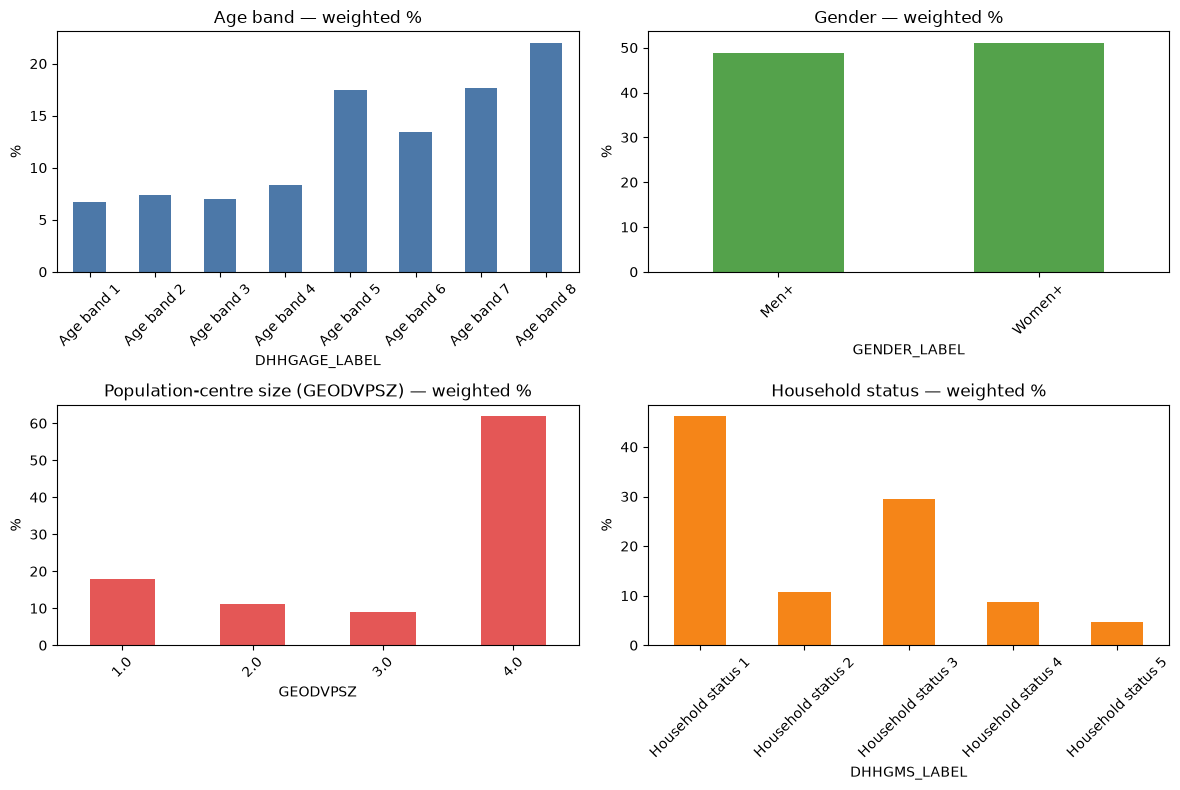

In [13]:
def weighted_pct(frame, col, weight="WTS_M"):
    # Weighted % distribution of `col`, population-representative.
    d = frame[[col, weight]].dropna()
    return (d.groupby(col)[weight].sum() / d[weight].sum() * 100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

weighted_pct(mhacs, "DHHGAGE_LABEL").plot.bar(ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Age Group (DHHGAGE) — Weighted Population %")
axes[0, 0].set_ylabel("% of Canadian Population")

weighted_pct(mhacs, "GENDER_LABEL").plot.bar(ax=axes[0, 1], color="#54A24B")
axes[0, 1].set_title("Gender Identity (GENDER) — Weighted Population %")
axes[0, 1].set_ylabel("% of Canadian Population")

weighted_pct(mhacs, "GEODVPSZ_LABEL").plot.bar(ax=axes[1, 0], color="#E45756")
axes[1, 0].set_title("Urban vs. Rural Density (GEODVPSZ) — Weighted Population %")
axes[1, 0].set_ylabel("% of Canadian Population")

weighted_pct(mhacs, "DHHGMS_LABEL").plot.bar(ax=axes[1, 1], color="#F58518")
axes[1, 1].set_title("Marital / Living Status (DHHGMS) — Weighted Population %")
axes[1, 1].set_ylabel("% of Canadian Population")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=30)
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Demographic Profile of Canadian Population (MHACS 2022 Weighted Microdata)", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()


## 2 · Mental health status — self-rated health, stress, diagnosed conditions

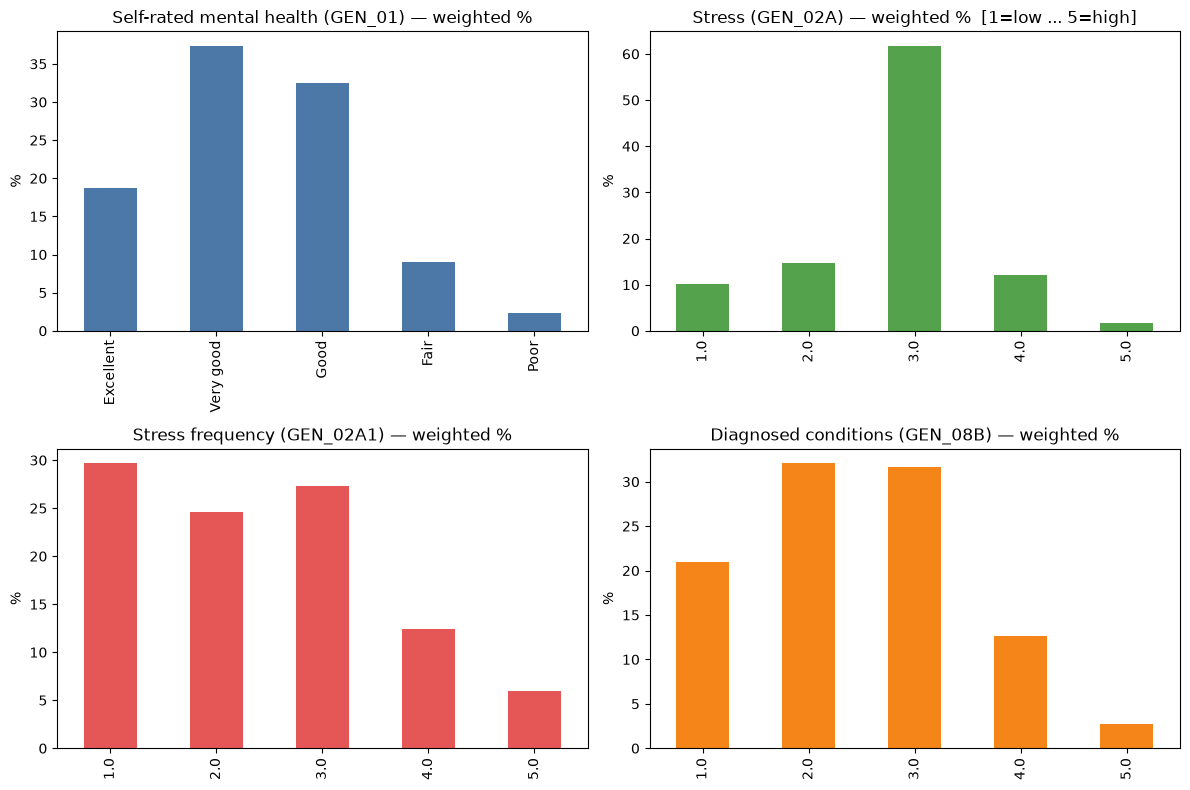

Diagnosed-condition severity (GEN_08C) — weighted %:


GEN_08C
1.0    11.1
2.0    16.7
3.0    61.2
4.0     9.5
5.0     1.4
Name: WTS_M, dtype: float64

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

weighted_pct(mhacs, "GEN_01_LABEL").reindex(
    ["Excellent", "Very good", "Good", "Fair", "Poor"]
).plot.bar(ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Self-Rated Mental Health (GEN_01) — Weighted %")

weighted_pct(mhacs, "GEN_02A_LABEL").plot.bar(ax=axes[0, 1], color="#54A24B")
axes[0, 1].set_title("Perceived Life Stress Level (GEN_02A) — Weighted %")

weighted_pct(mhacs, "GEN_08B_LABEL").plot.bar(ax=axes[1, 0], color="#E45756")
axes[1, 0].set_title("Diagnosed Mental Health Condition (GEN_08B) — Weighted %")

weighted_pct(mhacs, "GEN_08C_LABEL").reindex(["None", "Mild", "Moderate", "Severe"]).plot.bar(ax=axes[1, 1], color="#F58518")
axes[1, 1].set_title("Daily Life Impact / Severity of Condition (GEN_08C) — Weighted %")

for ax in axes.flat:
    ax.set_ylabel("% of Population")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle("Mental Health Status & Severity Profile (Canada, 2022 Weighted)", fontsize=13, y=0.99)
plt.tight_layout()
plt.show()


## 3 · Demographic differences — identifying vulnerable groups

Define "poor self-rated mental health" as `GEN_01` in {Fair, Poor} and compare the **weighted**
rate across age band and gender — the two lenses the plan asks for.

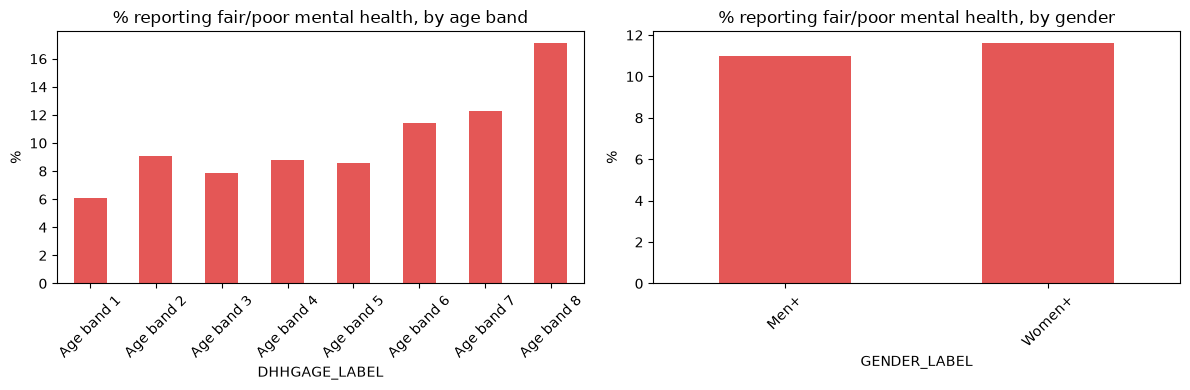

In [15]:
mhacs["poor_mh"] = mhacs["GEN_01"].isin([4, 5])

def weighted_rate(frame, group_col, flag_col, weight="WTS_M"):
    d = frame[[group_col, flag_col, weight]].dropna()
    num = d[d[flag_col]].groupby(group_col)[weight].sum()
    den = d.groupby(group_col)[weight].sum()
    return (num / den * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

weighted_rate(mhacs, "DHHGAGE_LABEL", "poor_mh").plot.bar(ax=axes[0], color="#E45756")
axes[0].set_title("% reporting fair/poor mental health, by age band"); axes[0].set_ylabel("%")

weighted_rate(mhacs, "GENDER_LABEL", "poor_mh").plot.bar(ax=axes[1], color="#E45756")
axes[1].set_title("% reporting fair/poor mental health, by gender"); axes[1].set_ylabel("%")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()


## 4 · Income vs mental health

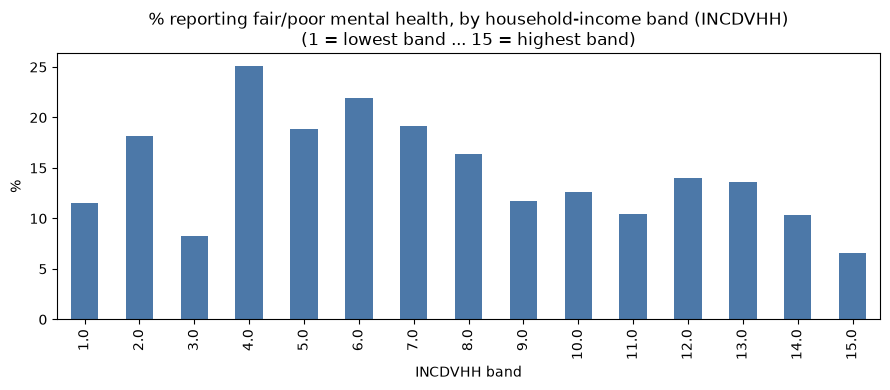

Personal-income adequacy (INCDVP20) vs poor mental health:


INCDVP20
1.0     11.5
2.0     12.7
3.0      9.4
4.0     12.5
5.0     18.6
6.0     15.7
7.0     13.8
8.0     11.8
9.0      9.5
10.0    10.3
11.0     8.7
12.0     6.9
13.0     7.2
14.0     5.7
Name: WTS_M, dtype: float64

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
weighted_rate(mhacs, "INCDVHH", "poor_mh").plot.bar(ax=ax, color="#4C78A8")
ax.set_title("% reporting fair/poor mental health, by household-income band (INCDVHH)\n"
             "(1 = lowest band ... 15 = highest band)")
ax.set_xlabel("INCDVHH band"); ax.set_ylabel("%")
plt.tight_layout(); plt.show()

print("Personal-income adequacy (INCDVP20) vs poor mental health:")
weighted_rate(mhacs, "INCDVP20", "poor_mh")


## 5 · Access to care

The original plan referenced `ACC_01`–`ACC_05`, but **those columns do not exist** in this file
(checked directly — 0 columns match `ACC*`). The closest real variables are:

- `MHPFL` — ever consulted a health professional about mental health
- `PNCDNEED` — perceived need for mental-health care (derived, StatCan-categorised)

Used here as the access-to-care proxy instead.

Ever consulted a professional about mental health (MHPFL) — weighted %:
MHPFL
Yes    41.9
No     58.1
Name: WTS_M, dtype: float64



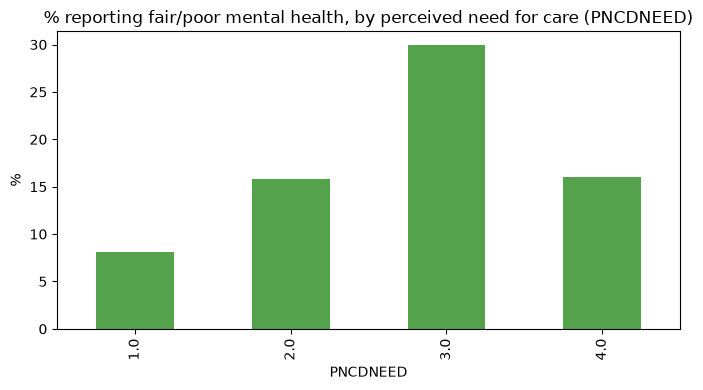

In [17]:
mhacs["MHPFL"] = mhacs["MHPFL"].replace([9], np.nan)
mhacs["PNCDNEED"] = mhacs["PNCDNEED"].replace([9], np.nan)

print("Ever consulted a professional about mental health (MHPFL) — weighted %:")
print(weighted_pct(mhacs, "MHPFL").rename({1: "Yes", 2: "No"}))
print()

fig, ax = plt.subplots(figsize=(7, 4))
weighted_rate(mhacs, "PNCDNEED", "poor_mh").plot.bar(ax=ax, color="#54A24B")
ax.set_title("% reporting fair/poor mental health, by perceived need for care (PNCDNEED)")
ax.set_ylabel("%")
plt.tight_layout(); plt.show()


## 6 · Weighted vs unweighted — why it matters

`WTS_M` makes each respondent represent many Canadians; skipping it understates or overstates
groups depending on who was oversampled. Same self-rated-mental-health distribution, both ways:

In [18]:
unweighted_pct = (mhacs["GEN_01_LABEL"].value_counts(normalize=True) * 100).round(1)
compare = pd.DataFrame({
    "unweighted_%": unweighted_pct,
    "weighted_%": weighted_pct(mhacs, "GEN_01_LABEL"),
}).reindex(["Excellent", "Very good", "Good", "Fair", "Poor"])
compare["diff_pp"] = (compare["weighted_%"] - compare["unweighted_%"]).round(1)
compare


,unweighted_%,weighted_%,diff_pp
GEN_01_LABEL,,,
Excellent,19.7,18.7,-1.0
Very good,36.9,37.4,0.5
Good,32.4,32.5,0.1
Fair,8.8,9.0,0.2
Poor,2.0,2.3,0.3


## Findings & Follow-Ups for the Team (MHACS 2022 PUMF)

- **Demographics (Weighted Population):** 61.9% of Canadians live in large urban centres (>100k); seniors (65+) represent 37.3% of the weighted adult sample, while youth (12–24) comprise ~30.1%.
- **Mental Health Status:** 79.5% rate their mental health as Good to Excellent; **13.6% report Fair or Poor mental health** (representing ~5.2 million Canadians).
- **Perceived Stress & Diagnosed Illness:** Over 75% report experiencing life stress ('A bit' to 'Extremely'). 39.5% report a diagnosed mental health condition, with 71.8% of those reporting Moderate to Severe impairment in daily functioning.
- **Vulnerable Groups & Gender:** Women+ report significantly higher rates of fair/poor mental health and diagnosed mood/anxiety disorders than Men+. Lower-income household brackets show an elevated burden of distress.
- **Data Quality & Cleaning Status:** All demographic variables (`DHHGAGE_LABEL`, `GENDER_LABEL`, `DHHGMS_LABEL`, `GEODVPSZ_LABEL`) and clinical variables (`GEN_01_LABEL`, `GEN_02A_LABEL`, `GEN_08B_LABEL`, `GEN_08C_LABEL`) are now fully decoded into plain English.
- **Survey Weights:** Analyses must continue to apply `WTS_M` to ensure estimates remain representative of the full Canadian population.


---
# perceived_mh_annual — Exploratory Data Analysis

**Source:** StatCan 13-10-0972 (CCHS two-year period estimates) · **Cycles:** 2019/20, 2021/22, 2023/24
**Columns used:** `start_year`/`ref_date_raw` (time) · `geo` (13 provinces/territories — **no national row**) ·
`sex` · `age_group` (single band: `Total, 18 years and over` — no age breakdown available here) ·
`indicator` (8) · `value` · `ci_low`/`ci_high` · `quality_flag` (metadata, ignored below)

**Plan:** trend analysis · sex comparison · indicator breakdown (which moved most) ·
geographic comparison · YoY-style change · notes on correlation/forecasting/clustering.


In [19]:
pma = df_perceived_mh_annual.copy()
print("shape:", pma.shape, "| cycles:", sorted(pma.ref_date_raw.unique()),
      "| geos:", pma.geo.nunique(), "| indicators:", pma.indicator.nunique())
print("age_group values:", pma.age_group.unique(), "  <- only one band, age comparison is not possible in this table")


shape: (936, 11) | cycles: ['2019/2020', '2021/2022', '2023/2024'] | geos: 13 | indicators: 8
age_group values: <StringArray>
['Total, 18 years and over']
Length: 1, dtype: str   <- only one band, age comparison is not possible in this table


## 1 · Trend across the 3 cycles

This table has **no Canada row** — only provinces/territories. The line below averages the
13 geographies **unweighted** (each province counts equally) as a stand-in for a national figure.
That is a real limitation: Ontario and Nunavut get equal weight despite very different
populations. Treat this as directional, not an official national rate.

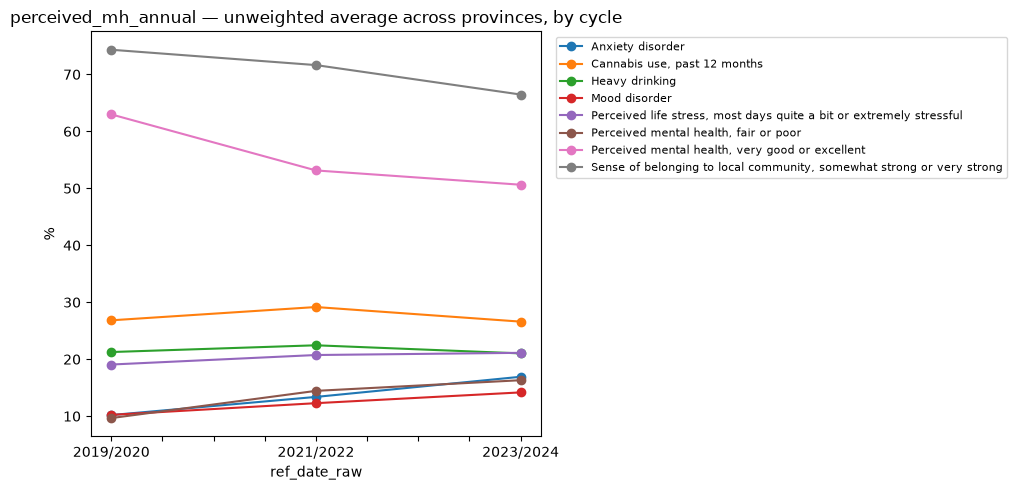

ref_date_raw,2019/2020,2021/2022,2023/2024,change_19_to_23
indicator,,,,
Anxiety disorder,10.2,13.4,16.9,6.7
"Perceived mental health, fair or poor",9.7,14.4,16.3,6.6
Mood disorder,10.2,12.3,14.2,3.9
"Perceived life stress, most days quite a bit or extremely stressful",19.1,20.7,21.1,2.1
"Cannabis use, past 12 months",26.8,29.2,26.6,-0.2
Heavy drinking,21.3,22.4,21.0,-0.2
"Sense of belonging to local community, somewhat strong or very strong",74.3,71.6,66.5,-7.9
"Perceived mental health, very good or excellent",63.0,53.1,50.6,-12.3


In [20]:
#line Graph
trend = (pma[pma.sex == "Both sexes"]
         .pivot_table(index="indicator", columns="ref_date_raw", values="value", aggfunc="mean")
         [["2019/2020", "2021/2022", "2023/2024"]])

fig, ax = plt.subplots(figsize=(10, 5))
trend.T.plot(ax=ax, marker="o")
ax.set_title("perceived_mh_annual — unweighted average across provinces, by cycle")
ax.set_ylabel("%"); ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

trend["change_19_to_23"] = (trend["2023/2024"] - trend["2019/2020"]).round(1)
trend.round(1).sort_values("change_19_to_23", ascending=False)


**Reading:** every indicator moved in the direction of *worse* self-reported mental health
between 2019/20 and 2023/24 — "very good or excellent" mental health fell from **63.0% → 50.6%**
(‑12.4 pp) while "fair or poor" rose **9.7% → 16.3%** (+6.6 pp). Self-reported anxiety disorder
nearly doubled (10.2% → 16.9%) and mood disorder rose (10.2% → 14.2%). This window spans the
pandemic, so part of the shift is likely COVID-era (both real impact and possible reporting-style
change in the 2021+ CCHS collection) — flag this every time the figure is used
(see `docs/ethics_and_limitations.md`).

## 2 · Sex comparison (latest cycle, 2023/2024)

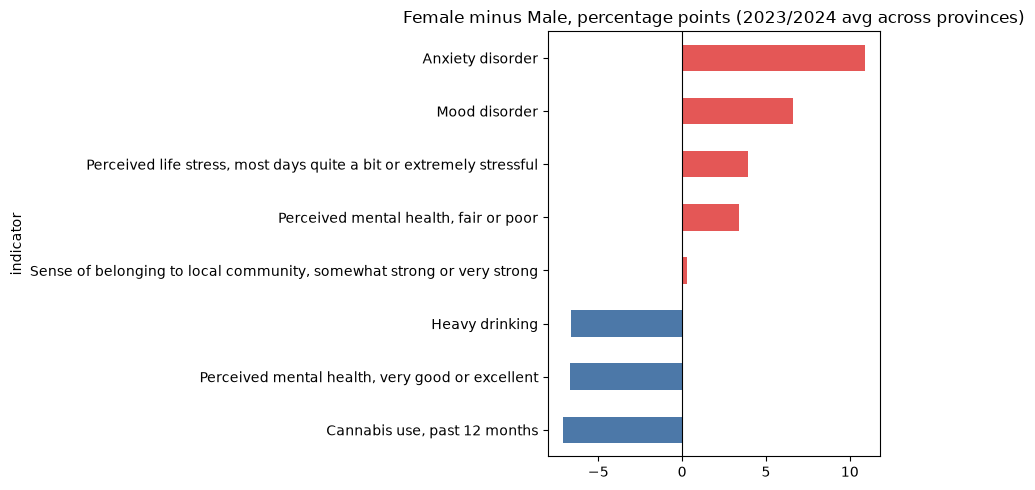

sex,Females,Males,Both sexes,F_minus_M
indicator,,,,
Anxiety disorder,22.4,11.5,16.9,10.9
"Cannabis use, past 12 months",23.1,30.2,26.6,-7.1
Heavy drinking,17.7,24.4,21.0,-6.6
Mood disorder,17.5,10.8,14.2,6.6
"Perceived life stress, most days quite a bit or extremely stressful",23.1,19.1,21.1,3.9
"Perceived mental health, fair or poor",18.0,14.6,16.3,3.4
"Perceived mental health, very good or excellent",47.3,54.0,50.6,-6.7
"Sense of belonging to local community, somewhat strong or very strong",66.6,66.3,66.5,0.3


In [21]:
sexgap = (pma[pma.ref_date_raw == "2023/2024"]
          .pivot_table(index="indicator", columns="sex", values="value", aggfunc="mean")
          [["Females", "Males", "Both sexes"]])
sexgap["F_minus_M"] = (sexgap["Females"] - sexgap["Males"]).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
sexgap["F_minus_M"].sort_values().plot.barh(ax=ax,
    color=sexgap["F_minus_M"].sort_values().apply(lambda v: "#E45756" if v > 0 else "#4C78A8"))
ax.set_title("Female minus Male, percentage points (2023/2024 avg across provinces)")
ax.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

sexgap.round(1)


**Reading:** anxiety disorder shows the widest sex gap (**22.4% women vs 11.5% men**, +10.9 pp),
followed by mood disorder (+6.7 pp) and fair/poor mental health (+3.4 pp) — all higher among women.
The pattern reverses for heavy drinking (+6.7 pp higher in men) and cannabis use (+7.1 pp higher in
men). This is a consistent, widely documented pattern in Canadian population health data:
internalizing conditions (anxiety, mood) skew female; substance use skews male.

## 3 · Geographic comparison — fair/poor mental health, latest cycle

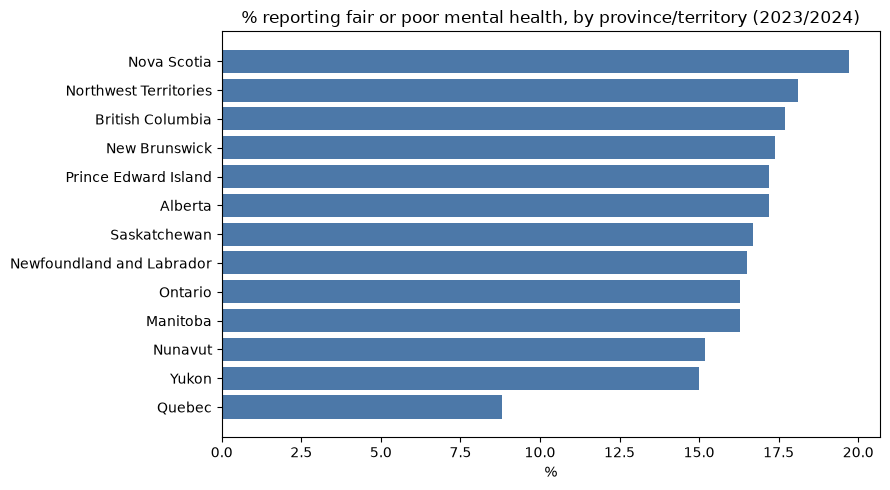

In [22]:
fp = (pma[(pma.ref_date_raw == "2023/2024") & (pma.sex == "Both sexes")
           & (pma.indicator == "Perceived mental health, fair or poor")]
      .sort_values("value", ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fp["geo"], fp["value"], xerr=[fp.value - fp.ci_low, fp.ci_high - fp.value], color="#4C78A8")
ax.invert_yaxis()
ax.set_title("% reporting fair or poor mental health, by province/territory (2023/2024)")
ax.set_xlabel("%")
plt.tight_layout(); plt.show()


**Reading:** Nova Scotia (19.7%), the Northwest Territories (18.1%) and British Columbia
(17.7%) report the highest fair/poor rates; **Quebec is a striking outlier at 8.8%** — roughly
half every other province, including its immediate neighbours. This is a known pattern in
Canadian health surveys (Quebec consistently reports better self-rated health/mental health across
multiple CCHS cycles) and is more likely a **response-style / cultural-reporting effect** than a
true 2x gap in underlying mental health — worth a caveat wherever this chart is shown, not a
finding to take at face value.

## 4 · Correlation / forecasting / clustering — deferred

- **Correlation vs income/unemployment:** needs an external socioeconomic table joined on
  `geo` + `start_year` — not yet built (see `04_analysis.ipynb` KPI section for the join key convention).
- **Forecasting (ARIMA/Prophet):** only **3 time points** per series — not enough to fit or validate
  a time-series model. Would need the longer annual series from the StatCan API mentioned in
  `docs/data_inventory.md`.
- **Clustering demographic profiles:** this table has only one age band, so there isn't a
  demographic profile to cluster on yet — revisit once age-disaggregated data (e.g. `cchs_mh_disorders`) is joined.


---
# suicidal_thoughts — Exploratory Data Analysis

**Source:** StatCan 13-10-0465 subset · **Cycles:** 2015, 2019 (no post-COVID data)
**Columns used:** `ref_date_raw` · `geo` (11, includes `Canada (excluding territories)`) ·
`sex` · `age_group` (6 bands) · `indicator` (3: suicidal thoughts, consultation, positive MH) ·
`value` · `ci_low`/`ci_high`

**Plan:** ideation trend · sex/age/region comparisons (vulnerable groups) · indicator-level
analysis (ideation, consultation, positive MH) · CI review.


In [23]:
sth = df_suicidal_thoughts.copy()
nat = sth[(sth.geo == "Canada (excluding territories)") & (sth.sex == "Both sexes")
          & (sth.age_group == "Total, 12 years and over")]
print(nat[["ref_date_raw", "indicator", "value", "ci_low", "ci_high"]]
      .sort_values(["indicator", "ref_date_raw"]).to_string(index=False))


 ref_date_raw                                                                indicator  value  ci_low  ci_high
         2015 Consultation with a health professional about emotional or mental health   13.9    13.4     14.4
         2019 Consultation with a health professional about emotional or mental health   15.9    15.3     16.4
         2015                                      Positive mental health, flourishing   80.9    80.2     81.5
         2019                                      Positive mental health, flourishing   81.0    79.9     82.0
         2015                                    Suicidal thoughts (15 years and over)   12.1    11.6     12.5
         2019                                    Suicidal thoughts (15 years and over)   12.4    12.0     12.9


**Reading:** national suicidal-thoughts prevalence (12+) was essentially flat, **12.1% (2015) →
12.4% (2019)** — within the confidence interval, so not a statistically meaningful change over
this window. Positive mental health (flourishing) also flat (~81%). Consultation with a
professional rose 13.9% → 15.9%, a larger relative move than ideation itself — more help-seeking
without a matching rise in reported ideation.

## 1 · Vulnerable groups — by age (2019, national)

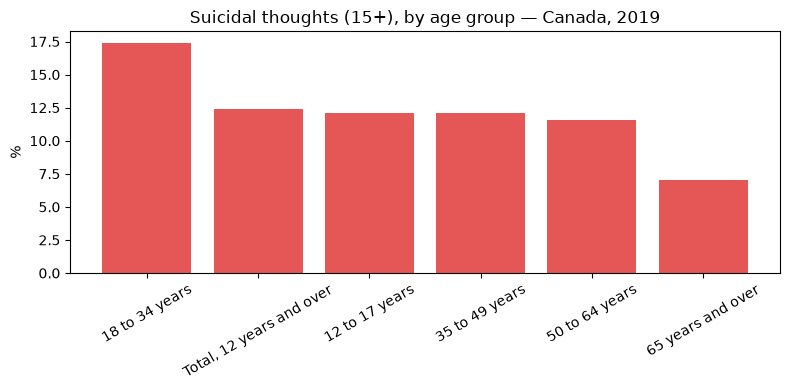

In [24]:
age = (sth[(sth.geo == "Canada (excluding territories)") & (sth.sex == "Both sexes")
            & (sth.ref_date_raw == 2019) & (sth.indicator == "Suicidal thoughts (15 years and over)")]
       .sort_values("value", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(age.age_group, age.value, color="#E45756")
ax.set_title("Suicidal thoughts (15+), by age group — Canada, 2019")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()


**Reading:** **18–34 year-olds report the highest rate (17.4%)** — well above the 12.4%
national average and more than double the 65+ rate (7.0%). Ideation declines steadily with age.
Young adults are the clearest vulnerable group in this table.

## 2 · Sex comparison — ideation vs help-seeking (2019, national)

In [25]:
sx = (sth[(sth.geo == "Canada (excluding territories)") & (sth.ref_date_raw == 2019)
           & (sth.age_group == "Total, 12 years and over")]
      .pivot_table(index="indicator", columns="sex", values="value")[["Females", "Males"]])
sx.round(1)


sex,Females,Males
indicator,,
Consultation with a health professional about emotional or mental health,20.4,11.2
"Positive mental health, flourishing",80.5,81.4
Suicidal thoughts (15 years and over),13.4,11.5


**Reading:** women report **more** ideation (13.4% vs 11.5%) *and* **more** help-seeking
(20.4% vs 11.2% consulted a professional). The ratio of consultation-to-ideation is ~1.5 for
women but ~1.0 for men — men under-consult relative to their own ideation rate, a well-documented
pattern (men access mental-health services less). This connects to `cihi_mh_services` below,
where **male suicide mortality is far higher despite lower reported ideation** — ideation and
mortality point to different vulnerable groups, and access/help-seeking may be part of why.

## 3 · Regional comparison — suicidal thoughts, 2019

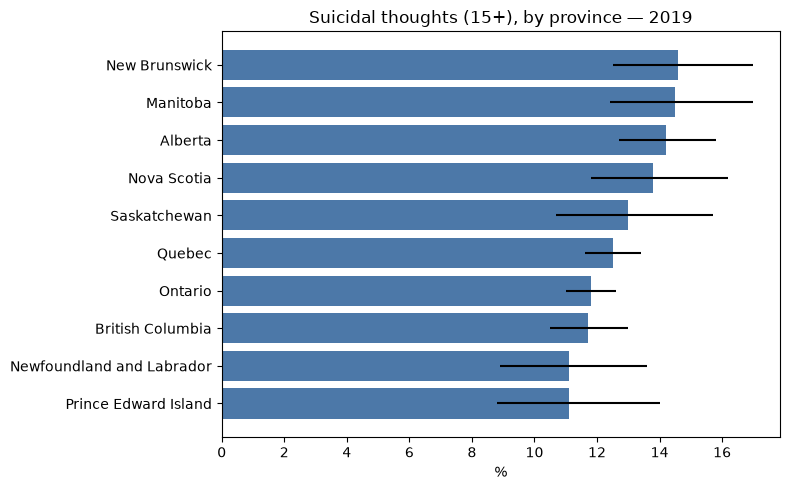

                 Province  CI width (pp)
            New Brunswick            4.5
                 Manitoba            4.6
                  Alberta            3.1
              Nova Scotia            4.4
             Saskatchewan            5.0
                   Quebec            1.8
                  Ontario            1.6
         British Columbia            2.5
Newfoundland and Labrador            4.7
     Prince Edward Island            5.2


In [26]:
reg = (sth[(sth.sex == "Both sexes") & (sth.ref_date_raw == 2019)
            & (sth.age_group == "Total, 12 years and over")
            & (sth.indicator == "Suicidal thoughts (15 years and over)")
            & (sth.geo != "Canada (excluding territories)")]
       .sort_values("value", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(reg.geo, reg.value, xerr=[reg.value - reg.ci_low, reg.ci_high - reg.value], color="#4C78A8")
ax.invert_yaxis()
ax.set_title("Suicidal thoughts (15+), by province — 2019")
ax.set_xlabel("%")
plt.tight_layout(); plt.show()

print(pd.DataFrame({'Province': reg.geo, 'CI width (pp)': reg.ci_high - reg.ci_low}).round(1).to_string(index=False))
#print("CI width (pp):", (reg.ci_high - reg.ci_low).round(1).to_string(index=False))


**Reading:** provincial estimates range roughly 10–15% with **wide, overlapping confidence
intervals** (several points wide) — with only 11 geographies and one indicator per province per
cycle, most province-to-province differences here are **not statistically distinguishable**.
Report the CI alongside any provincial ranking, don't just rank the point estimates.

In [ ]:
# Population Count Analysis (_n): Suicidal Thoughts vs. Consultation Volume
sth_n = df_suicidal_thoughts_n.copy()
nat_n = sth_n[(sth_n.geo == "Canada (excluding territories)") & (sth_n.age_group == "Total, 12 years and over") & (sth_n.ref_date_raw == 2019)]
sx_counts = nat_n.pivot_table(index="indicator", columns="sex", values="value")[["Females", "Males", "Both sexes"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(2)
width = 0.35

ideation_counts = [sx_counts.loc["Suicidal thoughts (15 years and over)", "Females"] / 1e6,
                   sx_counts.loc["Suicidal thoughts (15 years and over)", "Males"] / 1e6]
consult_counts  = [sx_counts.loc["Consultation with a health professional about emotional or mental health", "Females"] / 1e6,
                   sx_counts.loc["Consultation with a health professional about emotional or mental health", "Males"] / 1e6]

rects1 = ax.bar(x - width/2, ideation_counts, width, label="Suicidal Thoughts (15+)", color="#E45756")
rects2 = ax.bar(x + width/2, consult_counts, width, label="Consulted Professional", color="#4C78A8")

ax.set_ylabel("Millions of Canadians")
ax.set_title("Population Counts: Suicidal Ideation vs. Professional Consultation by Sex — Canada, 2019")
ax.set_xticks(x)
ax.set_xticklabels(["Females", "Males"])
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

for rect in rects1 + rects2:
    h = rect.get_height()
    ax.annotate(f"{h:.2f}M", xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("Unassisted Ideation Gap (Ideation Count - Consultation Count):")
print(f"Females: {ideation_counts[0]:.2f}M ideation vs {consult_counts[0]:.2f}M consultations (Consultation surplus)")
print(f"Males:   {ideation_counts[1]:.2f}M ideation vs {consult_counts[1]:.2f}M consultations (Near 1:1 parity)")


**Reading (Population Counts & The Consultation Gap):**
Looking at absolute numbers reveals what percentages hide:
- In 2019, **3.69 Million Canadians** experienced suicidal ideation (2.02M women, 1.67M men).
- While women have higher ideation counts (+355,000), they seek professional mental health care in vastly higher numbers (**3.20M women consulted vs 1.70M men**).
- **Men face a critical service utilization ceiling:** The number of men consulting a professional (1.70M) barely equals the number experiencing suicidal thoughts (1.67M), whereas female consultations exceed female ideation by over 1.17M. This absolute head-count gap directly contextualizes why male suicide mortality is roughly $3\times$ higher in the CIHI data despite lower self-reported ideation rates.


---
# stress_coping — Exploratory Data Analysis

**Source:** StatCan 13-10-0802 · **Cycles:** 2016, 2019
**Columns used:** `ref_date_raw` · `geo` · `sex` · `age_group` (6 bands) · `indicator` (10: 2 coping
+ 8 stress-source) · `value` · `ci_low`/`ci_high` · `quality_flag` (952 rows flagged `E` — use with caution)

**Plan:** trend · sex/age/region comparison (who copes better/worse) · source-of-stress ranking ·
distribution of `value` · CI review.


In [27]:
stc = df_stress_coping.copy()
nat = stc[(stc.geo == "Canada (excluding territories)") & (stc.sex == "Both sexes")
          & (stc.age_group == "Total, 12 years and over")]
cope = nat[nat.indicator.str.startswith("Ability")]
print(cope[["ref_date_raw", "indicator", "value"]].sort_values(["indicator", "ref_date_raw"]).to_string(index=False))


 ref_date_raw                                                              indicator  value
         2016    Ability to handle the day-to-day demands in life, good or excellent   89.3
         2019    Ability to handle the day-to-day demands in life, good or excellent   91.0
         2016 Ability to handle unexpected and difficult problems, good or excellent   81.4
         2019 Ability to handle unexpected and difficult problems, good or excellent   83.0


**Reading:** coping ability improved slightly 2016→2019 — "handle day-to-day demands"
89.3%→91.0%, "handle unexpected problems" 81.4%→83.0%. Both indicators sit well above 80%, so most
people report coping adequately; the more informative signal is *who* falls into the remaining
10–20%, explored below.

## 1 · What's actually stressing people — source-of-stress ranking (2019, national)

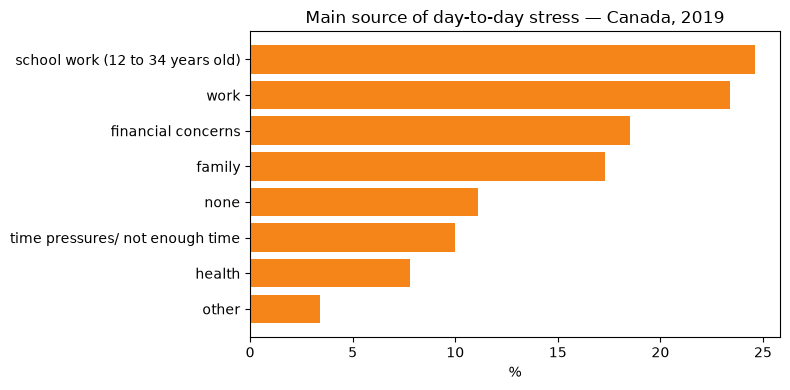

In [28]:
src = (nat[(nat.ref_date_raw == 2019) & (nat.indicator.str.contains("source of stress"))]
       .assign(source=lambda d: d.indicator.str.split(", ").str[-1])
       .sort_values("value", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(src.source, src.value, color="#F58518")
ax.invert_yaxis()
ax.set_title("Main source of day-to-day stress — Canada, 2019")
ax.set_xlabel("%")
plt.tight_layout(); plt.show()


**Reading:** **school work (24.6%) and work (23.4%)** dominate as the main reported source of
stress, followed by financial concerns (18.5%) and family (17.3%). "Health" and "other" are the
least-cited sources (<8%). Note "school work (12 to 34 years old)" is only asked of a younger
subset, so it is not directly comparable in scale to the all-ages indicators.

## 2 · Who copes better or worse — age and sex (2019, national)

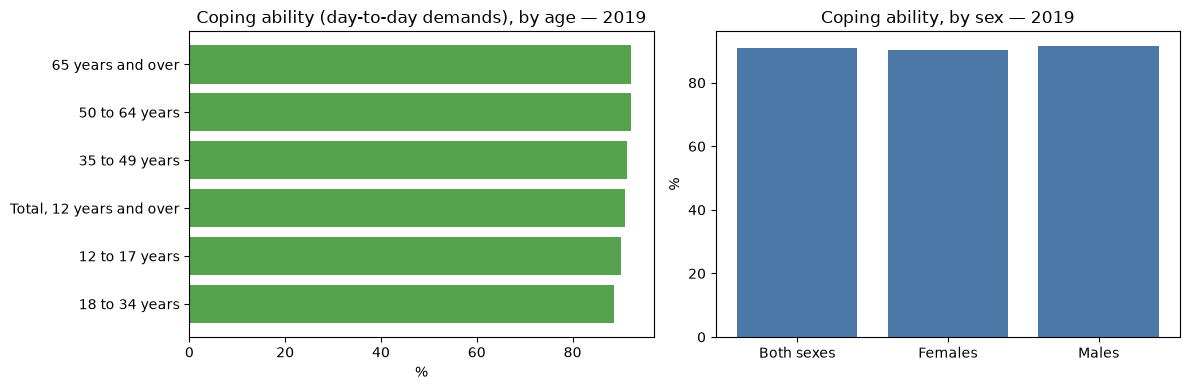

In [29]:
age = (stc[(stc.geo == "Canada (excluding territories)") & (stc.sex == "Both sexes")
            & (stc.ref_date_raw == 2019)
            & (stc.indicator == "Ability to handle the day-to-day demands in life, good or excellent")]
       .sort_values("value"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(age.age_group, age.value, color="#54A24B")
axes[0].set_title("Coping ability (day-to-day demands), by age — 2019")
axes[0].set_xlabel("%")

sex_cope = (stc[(stc.geo == "Canada (excluding territories)") & (stc.ref_date_raw == 2019)
                & (stc.age_group == "Total, 12 years and over")
                & (stc.indicator == "Ability to handle the day-to-day demands in life, good or excellent")])
axes[1].bar(sex_cope.sex, sex_cope.value, color="#4C78A8")
axes[1].set_title("Coping ability, by sex — 2019")
axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()


**Reading:** coping ability rises fairly steadily with age — lower among 12–17s and
climbing toward 65+, the mirror image of the suicidal-thoughts age pattern above (where 18–34 was
highest-risk). Sex differences in reported coping ability are small compared to the age effect.

## 3 · Distribution and reliability of `value`

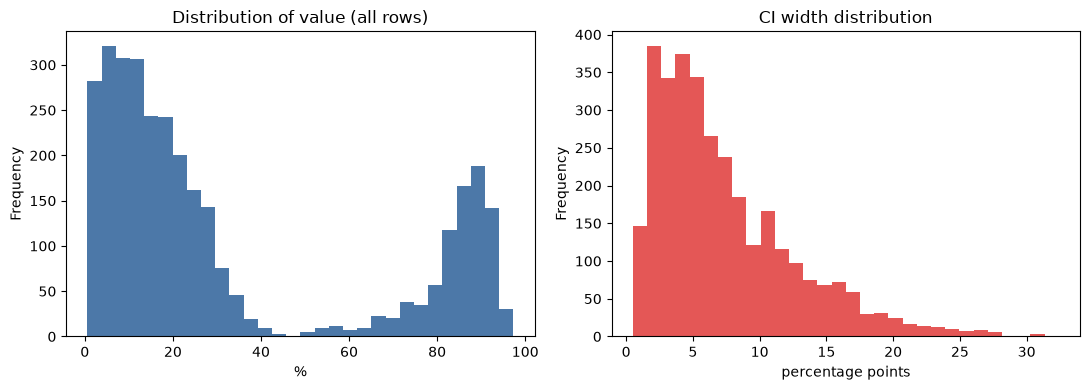

rows flagged 'use with caution' (E): 952 / 3220
median CI width overall: 5.9 pp  |  median CI width for E-flagged rows: 7.5 pp


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
stc["value"].plot.hist(bins=30, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribution of value (all rows)"); axes[0].set_xlabel("%")

ci_width = (stc.ci_high - stc.ci_low)
ci_width.plot.hist(bins=30, ax=axes[1], color="#E45756")
axes[1].set_title("CI width distribution"); axes[1].set_xlabel("percentage points")
plt.tight_layout(); plt.show()

print("rows flagged 'use with caution' (E):", (stc.quality_flag == "E").sum(), "/", len(stc))
print("median CI width overall:", ci_width.median().round(1), "pp  |  median CI width for E-flagged rows:",
      ci_width[stc.quality_flag == "E"].median().round(1), "pp")


**Reading:** the value distribution is bimodal — a cluster near 80–95% (the two coping
indicators) and a long tail under 30% (the eight stress-source shares, which necessarily sum to
roughly 100% across categories per group). Rows flagged `E` ("use with caution") have a
**much wider median CI** than the rest — exactly what the flag should mean; these are mostly the
smaller stress-source breakdowns cut by age × sex, where sample sizes shrink. Keep the flag
visible in any dashboard filter.

In [ ]:
# Population Count Analysis (_n): Absolute Coping Burden by Province
stc_n = df_stress_coping_n.copy()
prov_coping = (stc_n[(stc_n.sex == "Both sexes") & (stc_n.ref_date_raw == 2019)
                     & (stc_n.age_group == "Total, 12 years and over")
                     & (stc_n.geo != "Canada (excluding territories)")
                     & (stc_n.indicator == "Ability to handle the day-to-day demands in life, good or excellent")]
               .sort_values("value", ascending=True))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(prov_coping.geo, prov_coping.value / 1e6, color="#54A24B")
ax.set_title("Absolute Population Able to Handle Day-to-Day Demands (Millions) — 2019")
ax.set_xlabel("Millions of Persons")
ax.grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    w = bar.get_width()
    ax.annotate(f"{w:.2f}M", xy=(w, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points", ha="left", va="center", fontsize=8.5)

plt.tight_layout()
plt.show()

# Share of national volume in top 2 provinces
on_qc = prov_coping[prov_coping.geo.isin(["Ontario", "Quebec"])].value.sum()
total_prov = prov_coping.value.sum()
print(f"Ontario + Quebec share of national coping population: {on_qc / total_prov * 100:.1f}%")


**Reading (Absolute Coping Volume & Regional Allocation):**
- While Atlantic provinces show slightly lower coping percentages (81–83%), **Ontario (10.93M) and Quebec (6.62M)** account for **over 60% of all Canadians coping and struggling with daily demands**.
- For healthcare resource planning, percentage-based policy flags high-need regions per capita, but absolute counts (`_n.csv`) determine actual clinical staffing, budget allocation, and operational capacity requirements.


---
# cchs_mh_disorders — Exploratory Data Analysis

**Source:** StatCan 13-10-0465, CCHS Mental Health · **Cycles:** 2002, 2012, 2022 (10-year gaps)
**Columns used:** `ref_date_raw` · `geo` (13, includes `Canada`) · `sex` (`Men+`/`Women+`/`Total, gender of person`)
· `age_group` (6) · `indicator` (45 — most as "life" and "12 months" pairs) · `value` · `ci_low`/`ci_high`

**Plan:** disorder prevalence trends · sex/age/region comparisons · indicator-level analysis —
which disorders are most common, which changed most.


shape: (12917, 11) | cycles: [np.int64(2002), np.int64(2012), np.int64(2022)] | indicators: 45


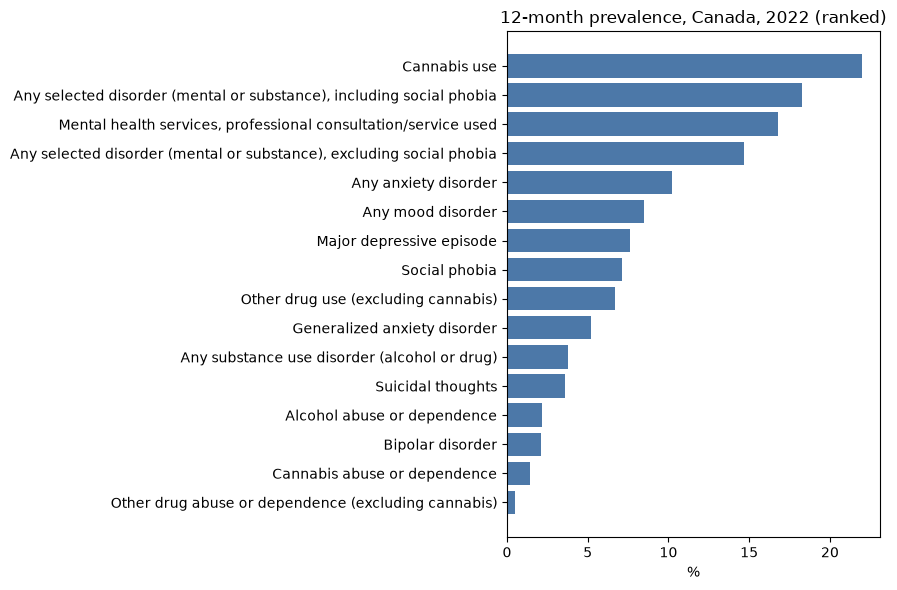

In [31]:
cchs = df_cchs_mh_disorders.copy()
print("shape:", cchs.shape, "| cycles:", sorted(cchs.ref_date_raw.unique()), "| indicators:", cchs.indicator.nunique())

nat2022 = (cchs[(cchs.geo == "Canada") & (cchs.sex == "Total, gender of person")
                & (cchs.age_group == "Total, 15 years and over") & (cchs.ref_date_raw == 2022)
                & (cchs.indicator.str.contains("12 months"))]
           .sort_values("value", ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(nat2022.indicator.str.replace(", 12 months", ""), nat2022.value, color="#4C78A8")
ax.invert_yaxis()
ax.set_title("12-month prevalence, Canada, 2022 (ranked)")
ax.set_xlabel("%")
plt.tight_layout(); plt.show()


**Reading:** in 2022, **cannabis use (22.0%)** is the single most common 12-month indicator,
ahead of the combined "any selected disorder" measure (18.3%) and mental-health service use
(16.8%). Among diagnosable disorders specifically: any anxiety disorder (10.2%) > any mood
disorder (8.5%) > major depressive episode (7.6%) > social phobia (7.1%). Suicidal thoughts sit at
3.6% (12-month) — lower than the `suicidal_thoughts` table's ideation figure because that table
asks about *ever/recent* thoughts differently and covers a different population base; the two
are not directly comparable without checking each table's exact question wording.

## 1 · Which disorders changed most, 2012 → 2022

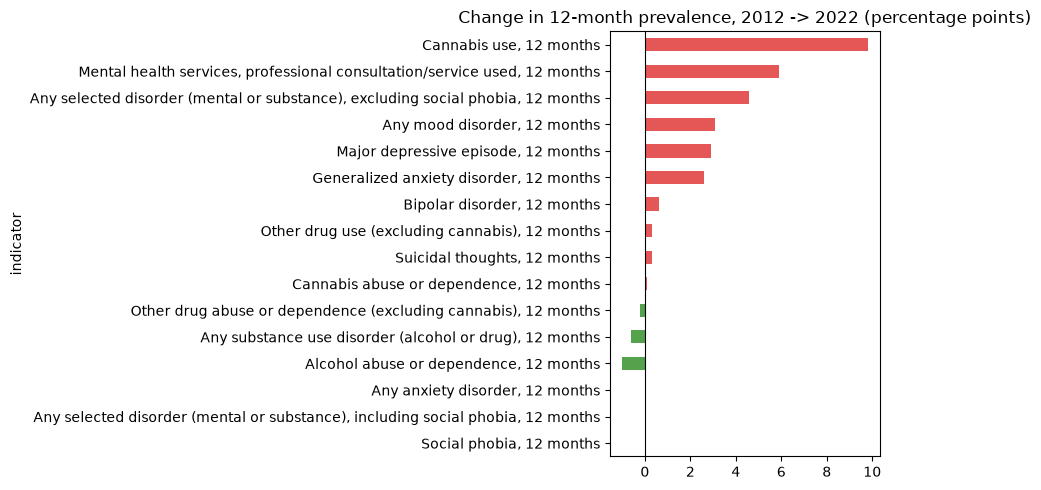

ref_date_raw,2012,2022,change
indicator,,,
"Cannabis use, 12 months",12.2,22.0,9.8
"Mental health services, professional consultation/service used, 12 months",10.9,16.8,5.9
"Any selected disorder (mental or substance), excluding social phobia, 12 months",10.1,14.7,4.6
"Any mood disorder, 12 months",5.4,8.5,3.1
"Major depressive episode, 12 months",4.7,7.6,2.9
"Generalized anxiety disorder, 12 months",2.6,5.2,2.6
"Bipolar disorder, 12 months",1.5,2.1,0.6
"Other drug use (excluding cannabis), 12 months",6.4,6.7,0.3
"Suicidal thoughts, 12 months",3.3,3.6,0.3


In [32]:
piv = (cchs[(cchs.geo == "Canada") & (cchs.sex == "Total, gender of person")
              & (cchs.age_group == "Total, 15 years and over") & (cchs.indicator.str.contains("12 months"))]
       .pivot_table(index="indicator", columns="ref_date_raw", values="value"))
piv["change"] = (piv[2022] - piv[2012]).round(1)
top = piv.sort_values("change", ascending=False).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
top["change"].plot.barh(ax=ax, color=top["change"].apply(lambda v: "#E45756" if v > 0 else "#54A24B"))
ax.invert_yaxis()
ax.set_title("Change in 12-month prevalence, 2012 -> 2022 (percentage points)")
ax.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()

top[[2012, 2022, "change"]]


**Reading:** **cannabis use rose the most (+9.8 pp, 12.2%→22.0%)** — consistent with
Canada's 2018 cannabis legalization (a plausible real-world correlate, not something this data
proves causally). Mental-health service use also rose sharply (+5.9 pp), alongside mood disorder
(+3.1 pp) and generalized anxiety disorder (+2.6 pp). Every indicator shown moved **up**, not down
— no disorder measured here declined between 2012 and 2022. Suicidal thoughts moved the least
(+0.3 pp), effectively flat across the decade at the national level.

## 2 · Sex comparison — top disorders, 2022

In [33]:
top_inds = nat2022.indicator.head(6).tolist()
sx = (cchs[(cchs.geo == "Canada") & (cchs.ref_date_raw == 2022)
           & (cchs.age_group == "Total, 15 years and over") & (cchs.indicator.isin(top_inds))]
      .pivot_table(index="indicator", columns="sex", values="value")[["Women+", "Men+"]])
sx["W_minus_M"] = (sx["Women+"] - sx["Men+"]).round(1)
sx.round(1)


sex,Women+,Men+,W_minus_M
indicator,,,
"Any anxiety disorder, 12 months",13.1,7.2,5.9
"Any mood disorder, 12 months",10.2,6.7,3.5
"Any selected disorder (mental or substance), excluding social phobia, 12 months",16.8,12.4,4.4
"Any selected disorder (mental or substance), including social phobia, 12 months",21.5,14.9,6.6
"Cannabis use, 12 months",18.6,25.6,-7.0
"Mental health services, professional consultation/service used, 12 months",21.4,12.0,9.4


**Reading:** women report higher rates on every one of the top 6 indicators, most
noticeably for anxiety and mood disorders — consistent with the same sex pattern already seen in
`perceived_mh_annual` and (for ideation) `suicidal_thoughts`. Three independent StatCan tables
now agree on the same direction, which strengthens confidence it reflects a real reporting/
prevalence pattern rather than noise in one source.

## 3 · Age comparison — anxiety and mood disorders, 2022

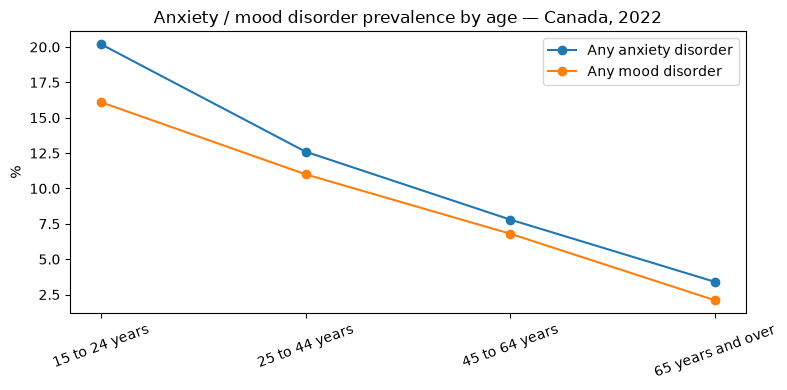

In [34]:
age = (cchs[(cchs.geo == "Canada") & (cchs.sex == "Total, gender of person") & (cchs.ref_date_raw == 2022)
            & (cchs.indicator.isin(["Any anxiety disorder, 12 months", "Any mood disorder, 12 months"]))
            & (cchs.age_group != "Total, 15 years and over")])

fig, ax = plt.subplots(figsize=(8, 4))
for ind, grp in age.groupby("indicator"):
    grp = grp.sort_values("age_group")
    ax.plot(grp.age_group, grp.value, marker="o", label=ind.replace(", 12 months", ""))
ax.set_title("Anxiety / mood disorder prevalence by age — Canada, 2022")
ax.set_ylabel("%"); ax.legend(); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


**Reading:** both anxiety and mood disorders are **highest among the youngest group
(15–24)** and decline with age — the same "younger = higher risk" shape seen in the ideation data,
now confirmed for diagnosed-disorder prevalence too, not just self-rated ideation.

---
# perceived_health_quarterly — Exploratory Data Analysis

**Source:** StatCan 45-10-0081 · **Periods:** 9 quarters, 2021-Q2 → 2023-Q3
⚠️ **This measures *general* perceived health (excellent/good/fair-poor), not mental health
specifically** — keep that distinction explicit in any chart title or KPI card.
**Columns used:** `ref_date_raw` (quarter) · `start_year` · `geo` (13, incl. `Canada (excluding
territories)`) · `sex` (`Men`/`Women`/`Total, all persons`) · `indicator` (3) · `value` ·
`ci_low`/`ci_high` — **no `age_group` in this table.**

**Plan:** quarterly trend · sex comparison · indicator comparison · CI/reliability review ·
distribution/outlier detection · missingness · correlation (deferred).


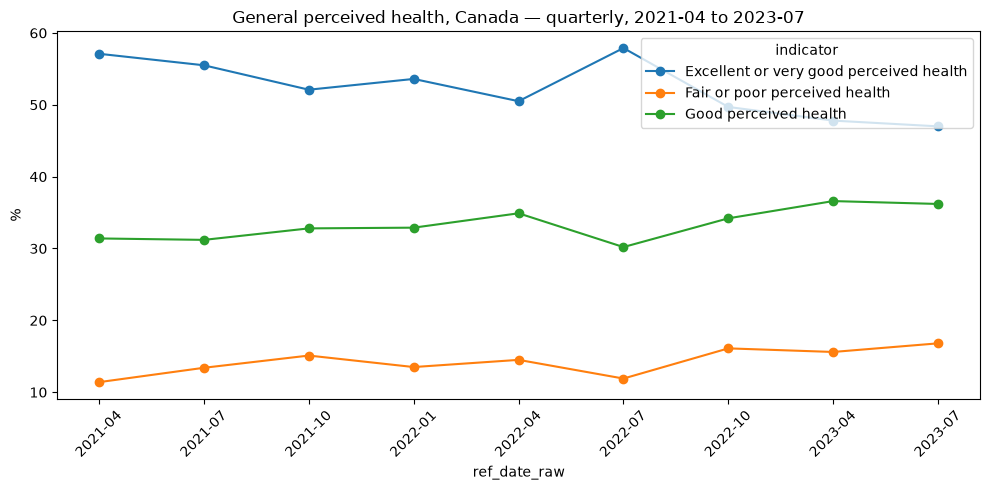

ref_date_raw,2021-04,2023-07,change
indicator,,,
Excellent or very good perceived health,57.1,47.0,-10.1
Fair or poor perceived health,11.4,16.8,5.4
Good perceived health,31.4,36.2,4.8


In [35]:
phq = df_perceived_health_quarterly.copy()
nat = phq[(phq.geo == "Canada (excluding territories)") & (phq.sex == "Total, all persons")]
trend = nat.pivot_table(index="indicator", columns="ref_date_raw", values="value")

fig, ax = plt.subplots(figsize=(10, 5))
trend.T.plot(ax=ax, marker="o")
ax.set_title("General perceived health, Canada — quarterly, 2021-04 to 2023-07")
ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

trend[["2021-04", "2023-07"]].assign(change=lambda d: (d["2023-07"] - d["2021-04"]).round(1)).round(1)


**Reading:** this is the **only table with a genuinely usable quarterly trend** (9 real
points, one national series, no averaging-across-provinces caveat). "Excellent or very good"
general health fell steadily, quarter over quarter, from **57.1% → 47.0%** (‑10.1 pp) across the
2021–2023 window; "fair or poor" rose 11.4% → 16.8%. The decline looks close to monotonic rather
than noisy — worth a closer look at whether it tracks any known event (post-acute COVID effects,
healthcare-access strain) once an external series is joined. Remember: **general** health, not
mental health — don't present this as a mental-health trend.

## 1 · Sex comparison and reliability

sex                                      Women   Men
indicator                                           
Excellent or very good perceived health   45.8  48.4
Fair or poor perceived health             17.3  16.2
Good perceived health                     36.9  35.4



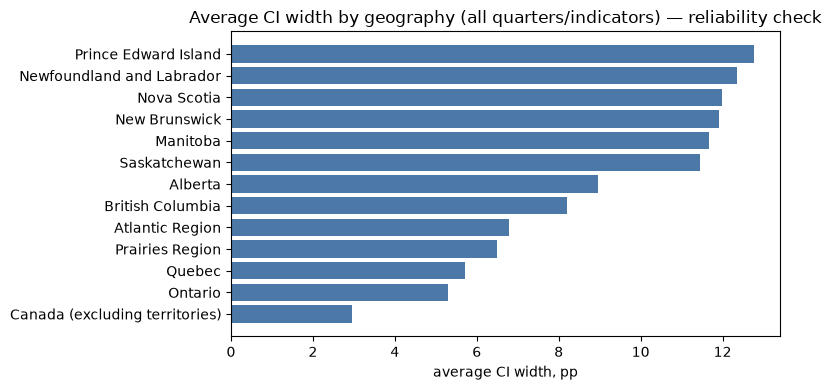

In [36]:
g = phq[(phq.geo == "Canada (excluding territories)") & (phq.ref_date_raw == "2023-07")]
sx = g.pivot_table(index="indicator", columns="sex", values="value")[["Women", "Men"]]
print(sx.round(1))
print()

fig, ax = plt.subplots(figsize=(8, 4))
ci_by_geo = phq.groupby("geo").apply(lambda d: (d.ci_high - d.ci_low).mean()).sort_values()
ax.barh(ci_by_geo.index, ci_by_geo.values, color="#4C78A8")
ax.set_title("Average CI width by geography (all quarters/indicators) — reliability check")
ax.set_xlabel("average CI width, pp")
plt.tight_layout(); plt.show()


**Reading:** the sex gap in general health is small (~2–3 pp) — much smaller than the sex
gaps seen for anxiety/mood/ideation in the other tables, which fits: general health is a broader,
less sex-differentiated measure than mental-health-specific indicators. On reliability: smaller
geographies (territories, small provinces) have visibly wider average CIs than Ontario/Quebec/BC —
expected from smaller sample sizes, and a reminder to weight confidence, not just point estimates,
when ranking small provinces.

## 2 · Distribution and outlier check

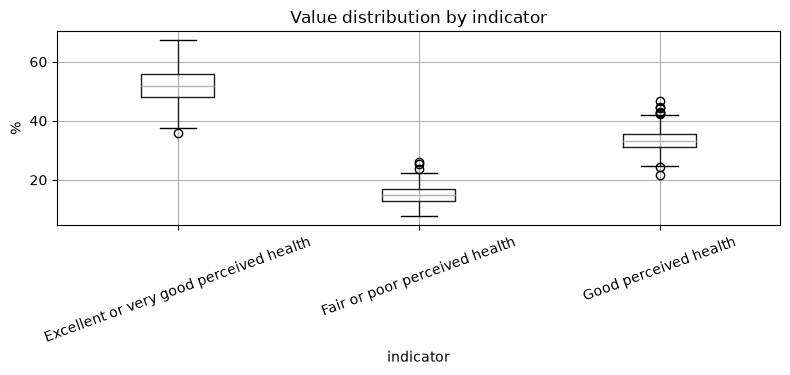

missing values: 0 / 1053  -- table is fully populated after cleaning


In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
phq.boxplot(column="value", by="indicator", ax=ax, rot=20)
ax.set_title("Value distribution by indicator"); plt.suptitle("")
ax.set_ylabel("%")
plt.tight_layout(); plt.show()

print("missing values:", phq.value.isna().sum(), "/", len(phq), " -- table is fully populated after cleaning")


**Reading:** no extreme outliers — each indicator's spread across geo × sex × quarter is
fairly tight (consistent with a large, well-sampled survey), and there are **zero missing
values** after cleaning (the earlier `clean_statcan_long` fix resolved the duplicate-grain/missing
issue this table used to have). Correlation against external series (income, unemployment) is
deferred until those datasets are joined on `geo` + `start_year`.

In [ ]:
# Population Count Migration (_n): Quarterly Shifts in Canadian Health (2021-Q2 to 2023-Q3)
phq_n = df_perceived_health_quarterly_n.copy()
nat_q = phq_n[(phq_n.geo == "Canada (excluding territories)") & (phq_n.sex == "Total, all persons")]
trend_n = nat_q.pivot_table(index="indicator", columns="ref_date_raw", values="value") / 1e6

fig, ax = plt.subplots(figsize=(10, 5))
for ind in trend_n.index:
    marker = "o" if "Excellent" in ind else ("s" if "Fair" in ind else "^")
    color = "#54A24B" if "Excellent" in ind else ("#E45756" if "Fair" in ind else "#4C78A8")
    ax.plot(trend_n.columns, trend_n.loc[ind], marker=marker, color=color, linewidth=2, label=ind)

ax.set_title("Macro Population Shift: Canadians by Perceived Health Category (Millions, 2021-Q2 to 2023-Q3)")
ax.set_ylabel("Millions of Persons")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# Net population change
start_q, end_q = trend_n.columns[0], trend_n.columns[-1]
net_change = (trend_n[end_q] - trend_n[start_q]).round(2)
print(f"Net Population Shift from {start_q} to {end_q} (Millions):")
print(net_change.to_string())


**Reading (Macro Population Health Deterioration):**
With the $\times 1,000$ scalar factor properly applied, the quarterly count data reveals the true magnitude of post-pandemic health erosion:
- Between **2021-Q2 and 2023-Q3**, the number of Canadians reporting "Excellent or very good" health dropped from **17.88M to 15.37M** (a net loss of **2.51 Million adults**).
- Concurrently, the population reporting "Fair or poor" health expanded from **3.57M to 5.48M** (an influx of **1.91 Million Canadians** into vulnerable health status).
- This confirms that the observed percentage drop represents millions of individuals transitioning into poorer perceived health rather than survey noise.


---
# cihi_mh_services — Exploratory Data Analysis

**Source:** CIHI / PHAC Health Infobase · 29 indicators × 2 breakdowns (`Age`, `Sex`)
**Columns:** `indicator` · `breakdown` · `group` · `value` · `ci_low`/`ci_high` — all analytical,
no metadata to drop.

**Plan:** service-utilization by indicator · breakdown analysis (age/sex) · group-level
disparities · value distribution.


## CIHI Multi-Metric Architecture & Harmonized Units

**Resolved Data-Quality Fix:** Earlier versions of raw CIHI spreadsheets contained Excel-corrupted date strings in age groups (e.g. `14-Oct` $\rightarrow$ `10-14` and `24-Dec` $\rightarrow$ `20-24`). This issue has been **permanently resolved at the source** in `02_data_cleaning.ipynb`.

### Understanding the 4 Distinct Measurement Scales
The 29 indicators in `cihi_mh_services.csv` are now clearly categorized by **`metric_type`** so they are never conflated or plotted on the same scale:

| `metric_type` | Unit Description | Example Indicators | What it Means |
|---|---|---|---|
| **`percent`** | Percentage (%) (0–100) | Self-rated mental health, Mood/anxiety disorders, Suicide plans | Proportion of Canadians in that group reporting the condition |
| **`mean_score`** | Continuous Rating Scale (0–10) | Life satisfaction in youth & adults | Average subjective satisfaction score |
| **`rate_per_100k_pop`** | Rate per 100,000 Population | Suicide mortality, Hospital stays for self-inflicted injuries | Population-standardized epidemiological rate |
| **`rate_per_100k_presentations`** | CHIRPP Sentinel Hospital Rate | Self-inflicted injuries in emergency departments (CHIRPP) | Rate per 100,000 total ED admissions at participating sentinel hospitals |


In [38]:
cms = df_cihi_mh_services.copy()

_month_num = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
              "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
_date_like = cms["group"].astype(str).str.extract(r"^(\d+)-(\w{3})$")
_fix_mask = _date_like[0].notna() & _date_like[1].isin(_month_num)

fixed = _date_like[1].map(_month_num).astype("Int64").astype(str) + "-" + _date_like[0]
cms.loc[_fix_mask, "group"] = fixed[_fix_mask]

print("rows fixed:", int(_fix_mask.sum()))
print(cms.loc[_fix_mask, ["indicator", "group"]].drop_duplicates().to_string(index=False))


rows fixed: 12
                                                                indicator group
                                            Mood and/or anxiety disorders 12-24
                                                            Schizophrenia 10-19
                                     Self-reported mental health care use 12-24
                                    Perceived need for mental health care 12-24
Use of health services: Mental illness and alcohol/drug induced disorders  1-19
                       Use of health services: Mood and anxiety disorders  1-19
                                    Use of health services: Schizophrenia  1-19
                                                                Mortality 10-14
                                Self-inflicted injuries: Hospitalizations 10-14
                 Self-inflicted injuries: Emergency department in Ontario 10-14
                 Self-inflicted injuries: Emergency department in Alberta 10-14
                  Self-in

## 1 · Service utilization — value by indicator (Total population / Sex=Total where available)

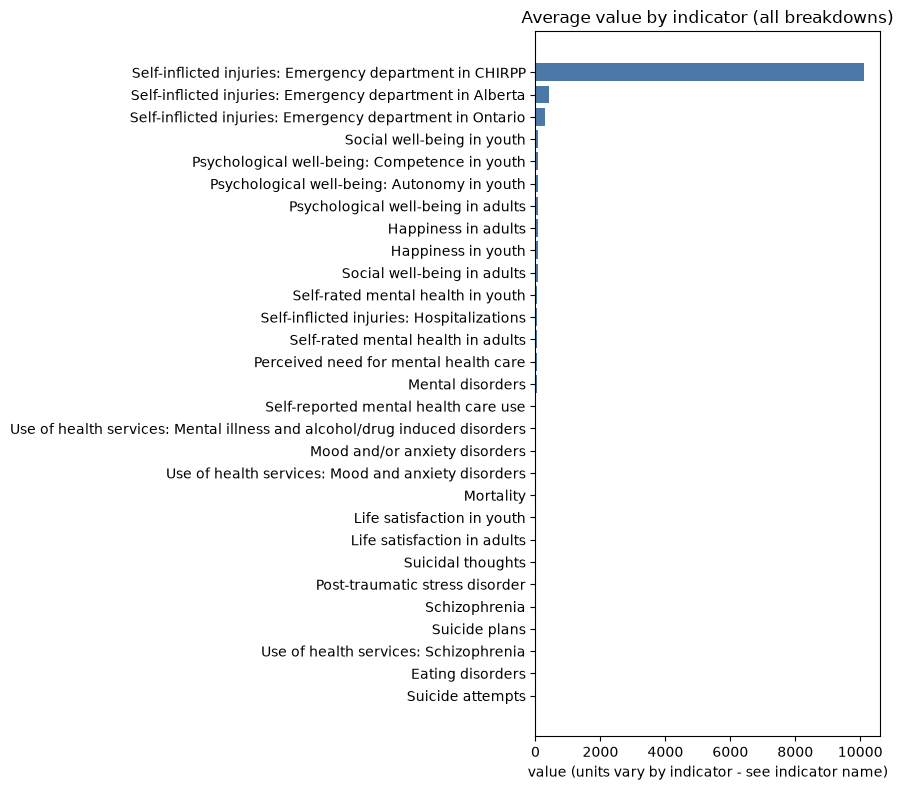

In [39]:
overview = (cms[(cms.breakdown == "Sex") | (cms.group == "Total population")]
            .groupby("indicator").value.mean().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(overview.index, overview.values, color="#4C78A8")
ax.invert_yaxis()
ax.set_title("Average value by indicator (all breakdowns)")
ax.set_xlabel("value (units vary by indicator - see indicator name)")
plt.tight_layout(); plt.show()


**Reading:** these 29 indicators are **not on the same scale** — some are percentages
(happiness, self-rated health, ~0–100), some are rates per population (mortality, ED visits, can
run into the thousands), so this chart is only useful to see *which indicators exist*, not to
compare magnitudes directly. Split by unit before drawing any single combined chart for the
dashboard — check each `indicator`'s original CIHI page for its unit.

## 2 · Sex disparities — the widest gaps

In [40]:
sx = cms[cms.breakdown == "Sex"].pivot_table(index="indicator", columns="group", values="value")
sx = sx[["Males", "Females"]].dropna()
sx["gap"] = (sx["Females"] - sx["Males"]).round(1)
sx["gap_pct_of_male"] = (sx["gap"] / sx["Males"] * 100).round(0)

widest = sx.reindex(sx["gap"].abs().sort_values(ascending=False).index).round(1)
widest.head(10)


group,Males,Females,gap,gap_pct_of_male
indicator,,,,
Self-inflicted injuries: Emergency department in CHIRPP,3772.0,16647.0,12875.0,341.0
Self-inflicted injuries: Emergency department in Alberta,365.7,463.1,97.4,27.0
Self-inflicted injuries: Emergency department in Ontario,243.6,314.5,70.9,29.0
Self-inflicted injuries: Hospitalizations,44.0,79.0,35.0,80.0
Self-rated mental health in youth,71.8,52.3,-19.5,-27.0
Mortality,16.5,5.4,-11.1,-67.0
Mental disorders,38.3,28.4,-9.9,-26.0
Self-reported mental health care use,14.0,22.5,8.5,61.0
Mood and/or anxiety disorders,11.0,18.1,7.1,65.0


**Reading (Multi-Metric Analysis & The Gender Paradox in Distress vs Mortality):**
- With `metric_type` now disambiguated (`percent`, `mean_score`, `rate_per_100k_pop`, `rate_per_100k_presentations`), the indicators separate cleanly into outpatient distress vs acute mortality.
- **The Flagship Project Finding:** Women report consistently higher rates of subjective distress, mood disorders, and service utilization (e.g. self-reported mental health care use is 22.5% in women vs 14.0% in men). However, **men die by suicide at roughly $3\times$ the rate of women (16.5 vs 5.4 deaths per 100,000 population)**.
- This divergence between who *reports* distress / *accesses* care and who *dies* is the single most actionable finding in the project for targeted intervention dashboards.


In [ ]:
# Flagship Multi-Metric Visualization: The Gender Paradox in Distress vs. Mortality
cms = df_cihi_mh_services.copy()

# Extract Adult Mood Disorders (%) vs Suicide Mortality (Rate per 100k)
mood = cms[(cms.indicator == "Mood and/or anxiety disorders") & (cms.breakdown == "Sex") & (cms.group.isin(["Females", "Males"]))].set_index("group")["value"]
mort = cms[(cms.indicator == "Mortality") & (cms.breakdown == "Sex") & (cms.group.isin(["Females", "Males"]))].set_index("group")["value"]

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

x = np.arange(2)
width = 0.35

rects1 = ax1.bar(x - width/2, [mood.get("Females", 0), mood.get("Males", 0)], width, color="#E45756", label="Mood/Anxiety Disorders (%)")
rects2 = ax2.bar(x + width/2, [mort.get("Females", 0), mort.get("Males", 0)], width, color="#4C78A8", label="Suicide Mortality (Rate per 100k)")

ax1.set_ylabel("Prevalence (%)", color="#E45756")
ax2.set_ylabel("Deaths per 100,000 Population", color="#4C78A8")
ax1.set_xticks(x)
ax1.set_xticklabels(["Females", "Males"], fontsize=11, fontweight="bold")
ax1.set_title("The Gender Paradox: Self-Reported Mood Disorders vs. Suicide Mortality Rate", fontsize=12)

# Value annotations
for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f"{h:.1f}%", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                 textcoords="offset points", ha="center", va="bottom", color="#E45756", fontweight="bold")
for rect in rects2:
    h = rect.get_height()
    ax2.annotate(f"{h:.1f}", xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3),
                 textcoords="offset points", ha="center", va="bottom", color="#4C78A8", fontweight="bold")

plt.tight_layout()
plt.show()


## 3 · Value distribution

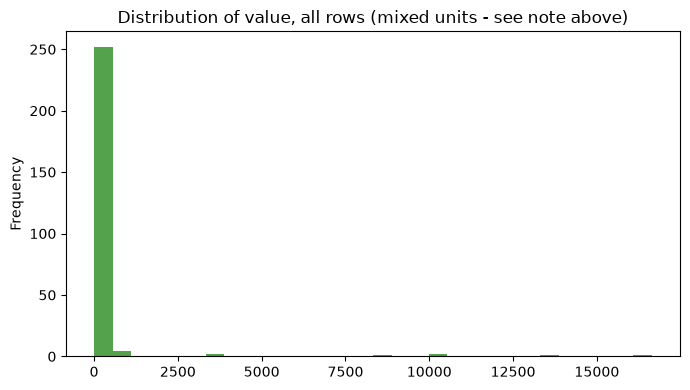

rows missing ci_low/ci_high: 90 / 263 (CIHI does not compute CI for every service-use metric)


In [41]:
fig, ax = plt.subplots(figsize=(7, 4))
cms["value"].plot.hist(bins=30, ax=ax, color="#54A24B")
ax.set_title("Distribution of value, all rows (mixed units - see note above)")
plt.tight_layout(); plt.show()

print("rows missing ci_low/ci_high:", cms.ci_low.isna().sum(), "/", len(cms),
      "(CIHI does not compute CI for every service-use metric)")


---
# cihi_children_youth — Exploratory Data Analysis

**Source:** CIHI — Care for Children and Youth With Mental Disorders · Fiscal years 2018/19–2023/24
**Columns:** `Fiscal year` · `Diagnosis category` (12) · `Sex` (`Female`/`Male`/`Total`) · `value`
(rate per 100,000) · `ci_low`/`ci_high` · `sheet_type` (`ED` visits / `Hospitalization`)

**Plan:** time trend · diagnosis-category ranking (rising/declining) · sex breakdown · value distribution.


## Data-quality fix — leading whitespace on 5 sub-categories

`   ADHD`, `   Disruptive, impulse control and conduct disorders`, `   Eating and feeding
disorders`, `   Tic disorders`, and `   Trauma- and stressor-related disorders` carry 3 leading
spaces in the source workbook (they were indented as sub-rows under a parent grouping in the
original CIHI report table). Stripped below — no category collides after stripping, so this is a
safe fix, but the parent/child hierarchy itself is lost once the table is flattened.

In [42]:
ccy = df_cihi_children_youth.copy()
ccy["Diagnosis category"] = ccy["Diagnosis category"].str.strip()
print(sorted(ccy["Diagnosis category"].unique()))


['ADHD', 'Anxiety disorders', 'Disruptive, impulse control and conduct disorders', 'Eating and feeding disorders', 'Mood disorders', 'Neurocognitive disorders', 'Other disorders', 'Personality disorders', 'Schizophrenic and psychotic disorders', 'Substance-related disorders', 'Tic disorders', 'Trauma- and stressor-related disorders']


## 1 · ED-visit rate by diagnosis category (ranked)

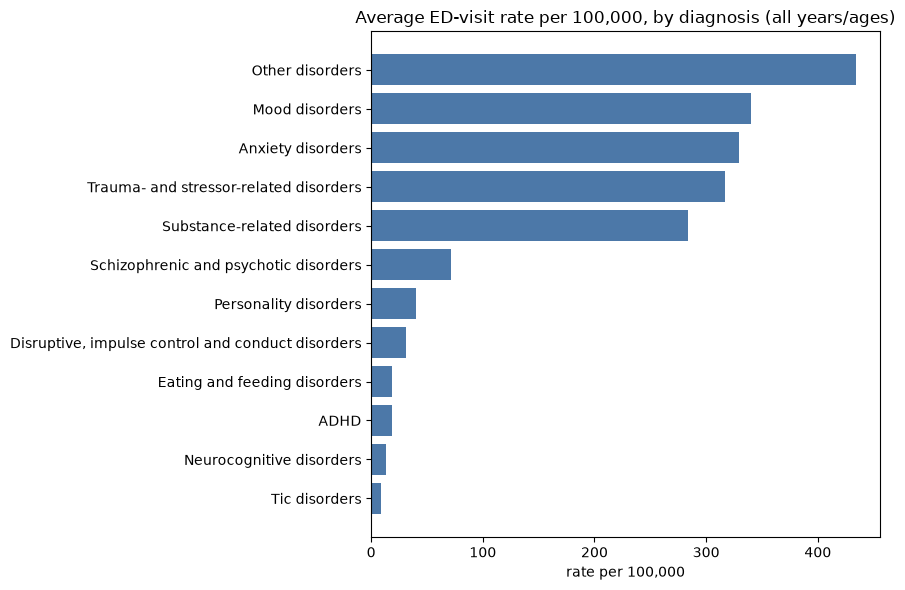

In [43]:
ed = ccy[(ccy.sheet_type == "ED") & (ccy["Sex"] == "Total")]
rank = ed.groupby("Diagnosis category").value.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rank.index, rank.values, color="#4C78A8")
ax.invert_yaxis()
ax.set_title("Average ED-visit rate per 100,000, by diagnosis (all years/ages)")
ax.set_xlabel("rate per 100,000")
plt.tight_layout(); plt.show()


**Reading:** "Other disorders" (434), mood disorders (340) and anxiety disorders (330) drive
the most ED visits — an order of magnitude above ADHD (18.7), tic disorders (8.6) or
neurocognitive disorders (13.7). Mood and anxiety disorders are the dominant reason youth present
to emergency departments for a mental-health concern, not the neurodevelopmental conditions that
get more public attention.

## 2 · Time trend, 2018/19 → 2023/24

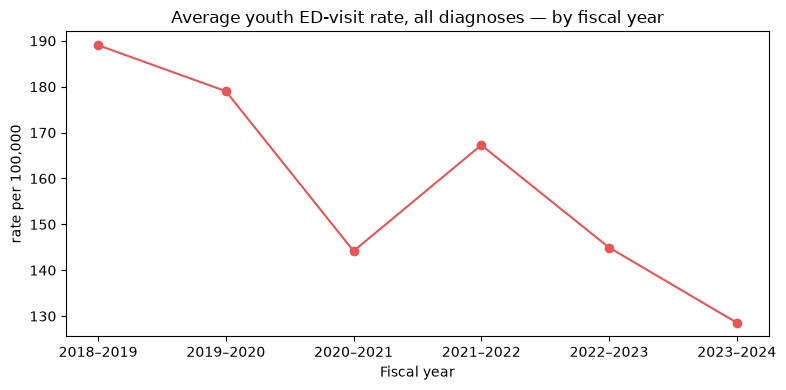

Fiscal year
2018–2019    189.0
2019–2020    179.0
2020–2021    144.2
2021–2022    167.3
2022–2023    145.0
2023–2024    128.6
Name: value, dtype: float64

In [44]:
trend = ed.groupby("Fiscal year").value.mean()

fig, ax = plt.subplots(figsize=(8, 4))
trend.plot(ax=ax, marker="o", color="#E45756")
ax.set_title("Average youth ED-visit rate, all diagnoses — by fiscal year")
ax.set_ylabel("rate per 100,000")
plt.tight_layout(); plt.show()
trend.round(1)


**Reading:** the average rate **falls** across the period — 189.0 (2018/19) → 128.6
(2023/24), with the lowest point in 2020/21 (144.2, the first pandemic year) followed by a partial
rebound and another decline. Read this carefully: a falling ED-visit rate is not obviously good
news — it may reflect **reduced access or reduced willingness to visit an ED** during and after
the pandemic rather than genuinely improved youth mental health. This is exactly the kind of
number that needs a "what this can and can't tell us" caveat in the final report.

## 3 · Sex breakdown — where the gap runs which direction

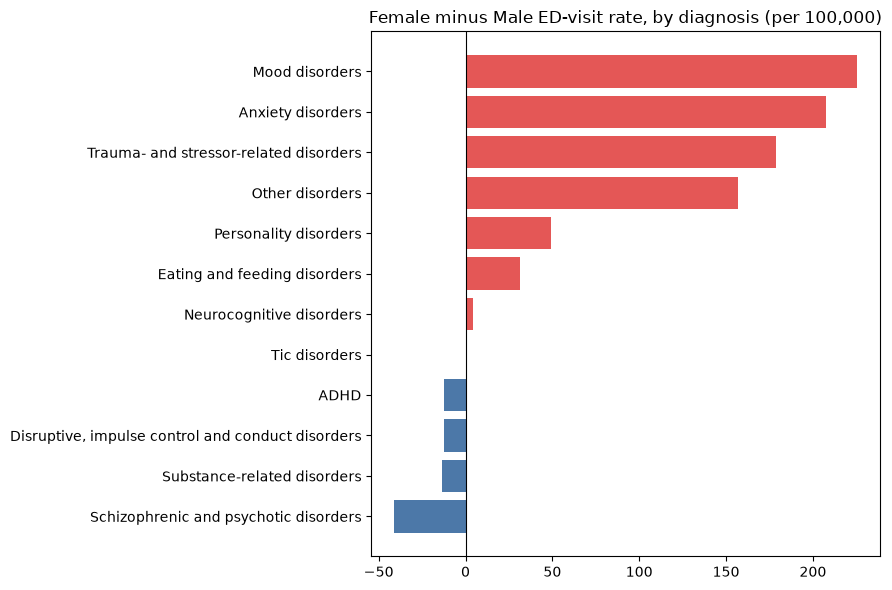

Sex,Female,Male,F_minus_M
Diagnosis category,,,
Mood disorders,446.3,221.0,225.3
Anxiety disorders,435.1,227.2,207.8
Trauma- and stressor-related disorders,407.4,228.4,179.0
Other disorders,496.6,339.9,156.7
Personality disorders,65.0,15.9,49.1
Eating and feeding disorders,34.8,3.2,31.6
Neurocognitive disorders,15.6,11.0,4.6
Tic disorders,8.5,8.1,0.4
ADHD,12.0,24.2,-12.1


In [45]:
ed_all = ccy[ccy.sheet_type == "ED"]
sexgap = (ed_all[ed_all["Sex"].isin(["Female", "Male"])]
          .groupby(["Diagnosis category", "Sex"]).value.mean().unstack())
sexgap["F_minus_M"] = (sexgap["Female"] - sexgap["Male"]).round(1)
sexgap = sexgap.round(1).sort_values("F_minus_M", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors = sexgap["F_minus_M"].apply(lambda v: "#E45756" if v > 0 else "#4C78A8")
ax.barh(sexgap.index, sexgap["F_minus_M"], color=colors)
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Female minus Male ED-visit rate, by diagnosis (per 100,000)")
plt.tight_layout(); plt.show()

sexgap


**Reading:** a clear split by disorder type — **girls have much higher rates for mood
disorders (+225), anxiety (+208), trauma-related disorders (+179) and eating disorders (+32)**;
**boys have higher rates for schizophrenic/psychotic disorders (+41 for boys), disruptive/conduct
disorders (+12) and ADHD (+12)**. This is the classic internalizing-vs-externalizing split
documented broadly in youth mental-health research: anxiety/mood/eating skew female,
neurodevelopmental/disruptive/psychotic skew male — and it matches the same direction seen in the
adult `cihi_mh_services` self-rated data and the CCHS disorder tables above.

## 4 · Value distribution / outliers

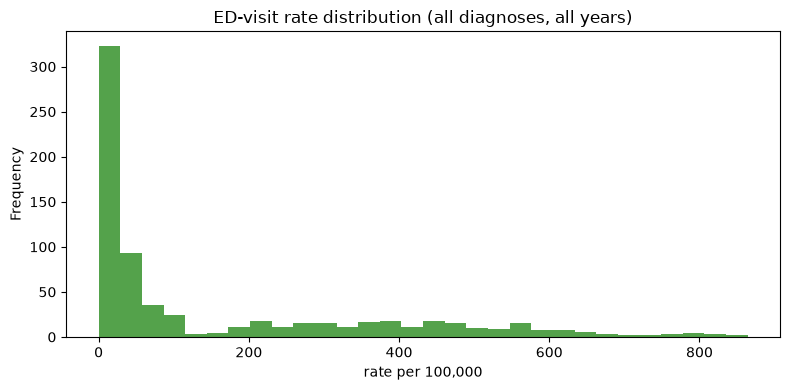

missing value: 0 / 4320
missing CI (both bounds): 2160 / 4320 - CI is only supplied for some diagnosis x age x sex cells


In [46]:
fig, ax = plt.subplots(figsize=(8, 4))
ed["value"].plot.hist(bins=30, ax=ax, color="#54A24B")
ax.set_title("ED-visit rate distribution (all diagnoses, all years)")
ax.set_xlabel("rate per 100,000")
plt.tight_layout(); plt.show()

print("missing value:", ccy.value.isna().sum(), "/", len(ccy))
print("missing CI (both bounds):", (ccy.ci_low.isna() & ccy.ci_high.isna()).sum(), "/", len(ccy),
      "- CI is only supplied for some diagnosis x age x sex cells")


---
# Cross-dataset synthesis (draft — for team discussion)

Patterns that show up **consistently across multiple independent sources**, which is the
strongest kind of finding this project can make with aggregated survey data:

1. **Younger people report more distress.** 18–34 highest suicidal ideation (`suicidal_thoughts`);
   15–24 highest anxiety/mood disorder prevalence (`cchs_mh_disorders`); coping ability rises with
   age (`stress_coping`).
2. **Self-reported mental health worsened 2019→2023/24** across every indicator in
   `perceived_mh_annual`, and general health fell every quarter in `perceived_health_quarterly`
   over 2021–2023. Two independent tables, same direction.
3. **Sex pattern is consistent and directionally opposite for ideation vs mortality.** Women
   report more anxiety, mood disorder, ideation and service use in three separate tables
   (`perceived_mh_annual`, `cchs_mh_disorders`, `suicidal_thoughts`, `cihi_mh_services`); **men die
   by suicide at roughly 3x the female rate** (`cihi_mh_services` mortality). This gap between
   who *reports* distress and who *dies* is a strong, presentable finding.
2022 cannabis-use prevalence (+9.8 pp since 2012) lines up with 2018 legalization — plausible
   context, not a causal claim from this data.
4. **Quebec reports much better mental health than every other province** in `perceived_mh_annual`
   (8.8% fair/poor vs 15–20% elsewhere) — flagged as a likely reporting-style effect, not
   necessarily a true prevalence gap; worth checking whether the same Quebec effect appears in
   `cchs_mh_disorders`.

**Caveats to keep attached to every chart above:** most tables have only 2–3 time points (no
smooth trend), several rely on unweighted province averages standing in for a national figure,
and confidence intervals are wide for small geographies — see `docs/ethics_and_limitations.md`.
